# Lecciones 3-4: Series de Fourier

**Ampliación de Matemáticas - GIERM**

---

## Objetivos de aprendizaje

- Calcular los coeficientes de Fourier (trigonométricos y complejos) de funciones periódicas
- Distinguir cuándo usar series completas, de senos o de cosenos (extensiones pares/impares)
- Reconocer patrones de simetría para predecir qué coeficientes se anulan **antes** de calcular
- Representar gráficamente aproximaciones parciales y espectros de amplitud
- Aplicar la identidad de Parseval para sumar series numéricas
- Dominar los 12 tipos de ejercicios del catálogo final

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['figure.dpi'] = 100

COLOR_PRINCIPAL = '#2171b5'
COLOR_RECTA = '#cb181d'
COLOR_PUNTO = '#238b45'
COLOR_AUX1 = '#ff7f0e'
COLOR_AUX2 = '#9467bd'
COLOR_AUX3 = '#8c564b'

# Paleta para N creciente
COLORES_N = ['#a6cee3', '#1f78b4', '#b2df8a', '#33a02c', '#fb9a99',
             '#e31a1c', '#fdbf6f', '#ff7f00', '#cab2d6', '#6a3d9a']

print('Configuracion lista.')

Configuracion lista.


---

## 1. Serie trigonométrica de Fourier

Sea $f(t)$ una función periódica de periodo $T$ y frecuencia angular $\omega = 2\pi/T$. Su **serie de Fourier trigonométrica** es:

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty} \left[ a_n \cos(n\omega t) + b_n \sin(n\omega t) \right]}$$

donde los **coeficientes de Fourier** son:

$$\boxed{a_0 = \frac{2}{T} \int_{-T/2}^{T/2} f(t)\, dt}$$

$$\boxed{a_n = \frac{2}{T} \int_{-T/2}^{T/2} f(t) \cos(n\omega t)\, dt, \qquad n \geq 1}$$

$$\boxed{b_n = \frac{2}{T} \int_{-T/2}^{T/2} f(t) \sin(n\omega t)\, dt, \qquad n \geq 1}$$

**Interpretación física:**
- $a_0/2$ es el **valor medio** de la función
- $a_n$ mide la "cantidad de $\cos(n\omega t)$" presente en $f$
- $b_n$ mide la "cantidad de $\sin(n\omega t)$" presente en $f$
- A mayor $n$, mayor frecuencia $\to$ captura detalles más finos

**Nota:** La integral se puede tomar sobre cualquier intervalo de longitud $T$, por ejemplo $[0, T]$ o $[-T/2, T/2]$.

---

## 2. Serie de Fourier en forma compleja

Usando la fórmula de Euler $e^{j\theta} = \cos\theta + j\sin\theta$, la serie se escribe de forma compacta:

$$\boxed{f(t) \sim \sum_{n=-\infty}^{\infty} c_n \, e^{jn\omega t}}$$

con coeficientes complejos:

$$\boxed{c_n = \frac{1}{T} \int_{-T/2}^{T/2} f(t)\, e^{-jn\omega t}\, dt}$$

### Relaciones entre coeficientes

| Relación | Fórmula |
|----------|--------|
| $c_0$ | $c_0 = \dfrac{a_0}{2}$ |
| $c_n$ ($n > 0$) | $c_n = \dfrac{a_n - j b_n}{2}$ |
| $c_{-n}$ ($n > 0$) | $c_{-n} = \dfrac{a_n + j b_n}{2}$ |
| $a_n$ desde $c_n$ | $a_n = c_n + c_{-n} = 2\,\text{Re}(c_n)$ |
| $b_n$ desde $c_n$ | $b_n = j(c_n - c_{-n}) = -2\,\text{Im}(c_n)$ |
| Amplitud | $|c_n| = \dfrac{1}{2}\sqrt{a_n^2 + b_n^2}$ |

**Ventaja de la forma compleja:** una sola integral en lugar de tres. Además, el **espectro de amplitud** $|c_n|$ vs $n$ es la herramienta clave para analizar señales.

---

## 3. Series de medio rango (extensiones par e impar)

Cuando $f$ está definida solo en $[0, L]$, podemos extenderla a $[-L, L]$ de dos formas:

### 3.1 Serie de senos (extensión impar)

Se extiende como función **impar**: $f(-t) = -f(t)$. Resultado:

$$\boxed{f(t) \sim \sum_{n=1}^{\infty} b_n \sin\left(\frac{n\pi t}{L}\right), \qquad b_n = \frac{2}{L} \int_0^L f(t) \sin\left(\frac{n\pi t}{L}\right) dt}$$

### 3.2 Serie de cosenos (extensión par)

Se extiende como función **par**: $f(-t) = f(t)$. Resultado:

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos\left(\frac{n\pi t}{L}\right), \qquad a_n = \frac{2}{L} \int_0^L f(t) \cos\left(\frac{n\pi t}{L}\right) dt}$$

**Truco para el examen:** si el enunciado dice "desarrolle en serie de senos/cosenos en $[0, L]$", no hay que extender explícitamente la función; basta con calcular los coeficientes con la integral en $[0, L]$. La extensión determina qué tipo de serie usar.

---

## 4. Tabla de reconocimiento de patrones (FUNDAMENTAL)

Esta es la herramienta más poderosa para series de Fourier. **Antes de calcular nada**, examina las propiedades de $f$ y deduce qué coeficientes se anulan:

| Propiedad de $f$ | Efecto en coeficientes | Qué esperar |
|---|---|---|
| $f$ **par** ($f(-t) = f(t)$) | $b_n = 0$ para todo $n$ | Solo cosenos |
| $f$ **impar** ($f(-t) = -f(t)$) | $a_n = 0$, $a_0 = 0$ | Solo senos |
| **Simetría de media onda** $f(t + T/2) = -f(t)$ | Armónicos pares $= 0$ | Solo $n$ impar |
| $f$ **continua** | $|c_n| \sim 1/n^2$ | Decaimiento rápido |
| $f$ con **discontinuidades de salto** | $|c_n| \sim 1/n$ | Decaimiento lento, Gibbs |
| $f$ **real** | $c_{-n} = \overline{c_n}$ | Simetría conjugada |
| $f$ **real y par** | $c_n$ real | Sin espectro de fase |
| $f$ **real e impar** | $c_n$ puramente imaginario | Fase $\pm 90°$ |
| $f$ con **valor medio cero** | $a_0 = 0$, $c_0 = 0$ | Sin componente DC |

### Cómo usar esta tabla en un examen

1. **Paso 0 (antes de calcular):** examinar simetrías de $f$
2. Si $f$ es par $\to$ no pierdas tiempo calculando $b_n$
3. Si $f$ es impar $\to$ no pierdas tiempo calculando $a_n$ ni $a_0$
4. Si tiene simetría de media onda $\to$ solo calcula armónicos impares
5. Si es combinación (par + media onda) $\to$ solo cosenos con $n$ impar

**Error frecuente:** calcular todos los coeficientes sin explotar simetrías. Esto triplica el trabajo innecesariamente.

---

## 5. Propiedades de la serie de Fourier

### 5.1 Desplazamiento temporal

Si $f(t)$ tiene coeficientes $c_n$, entonces:

$$f(t - t_0) \sim \sum_{n=-\infty}^{\infty} c_n \, e^{-jn\omega t_0} \, e^{jn\omega t}$$

**Efecto:** cambia las **fases** pero NO las amplitudes $|c_n|$. El espectro de amplitud es invariante ante desplazamientos.

### 5.2 Escalado temporal

Si $f(t)$ tiene periodo $T$, entonces $f(at)$ tiene periodo $T/|a|$ y:
$$c_n^{\text{nueva}} = c_n^{\text{original}}$$

Los coeficientes son los mismos, pero las frecuencias cambian.

### 5.3 Derivación

Si $f(t) \sim \sum c_n e^{jn\omega t}$, entonces:

$$f'(t) \sim \sum (jn\omega)\, c_n\, e^{jn\omega t}$$

La derivación multiplica por $jn\omega$ $\to$ amplifica armónicos altos $\to$ derivar "aguza" la señal.

### 5.4 Integración

$$\int f(t)\,dt \sim C + \sum_{n \neq 0} \frac{c_n}{jn\omega}\, e^{jn\omega t}$$

La integración divide por $jn\omega$ $\to$ atenúa armónicos altos $\to$ integrar "suaviza" la señal.

---

## 6. Identidad de Parseval

$$\boxed{\frac{1}{T} \int_{-T/2}^{T/2} |f(t)|^2\, dt = \sum_{n=-\infty}^{\infty} |c_n|^2 = \frac{a_0^2}{4} + \frac{1}{2} \sum_{n=1}^{\infty} (a_n^2 + b_n^2)}$$

**Interpretación:** la **potencia media** de la señal es igual a la suma de las potencias de cada armónico.

### Aplicación: sumar series numéricas

La identidad de Parseval permite calcular sumas de series que de otro modo serían muy difíciles. Estrategia:

1. Buscar una función $f$ cuya serie de Fourier contenga la serie que nos piden
2. Calcular $\frac{1}{T}\int |f|^2 dt$ directamente
3. Igualar con $\sum |c_n|^2$
4. Despejar la suma buscada

**Ejemplo clásico:** Para $f(t) = t$ en $[-\pi, \pi]$ (función impar), se obtiene $b_n = \frac{2(-1)^{n+1}}{n}$. Aplicando Parseval:

$$\frac{1}{2\pi}\int_{-\pi}^{\pi} t^2\,dt = \frac{1}{2}\sum_{n=1}^{\infty} \frac{4}{n^2} \implies \frac{\pi^2}{3} = 2\sum \frac{1}{n^2} \implies \boxed{\sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{\pi^2}{6}}$$

---

## 7. Convergencia

### Condiciones de Dirichlet

Si $f$ satisface en cada periodo:
1. Un número finito de discontinuidades
2. Un número finito de máximos y mínimos
3. $\int_{-T/2}^{T/2} |f(t)|\,dt < \infty$

entonces la serie de Fourier **converge** a:
- $f(t)$ en puntos de continuidad
- $\dfrac{f(t^+) + f(t^-)}{2}$ en puntos de discontinuidad (promedio de límites laterales)

### Fenómeno de Gibbs

En las discontinuidades de salto, las sumas parciales de Fourier presentan un **sobreimpulso** de aproximadamente el **9%** del salto, que **no desaparece** al aumentar $N$ (solo se hace más estrecho).

**Truco para el examen:** si preguntan "¿a qué converge la serie en $t_0$?" donde hay una discontinuidad, la respuesta es siempre el promedio de los límites laterales:

$$S(t_0) = \frac{f(t_0^+) + f(t_0^-)}{2}$$

---

## 8. Gráficas: Ondas fundamentales y sus series de Fourier

### 8.1 Onda cuadrada

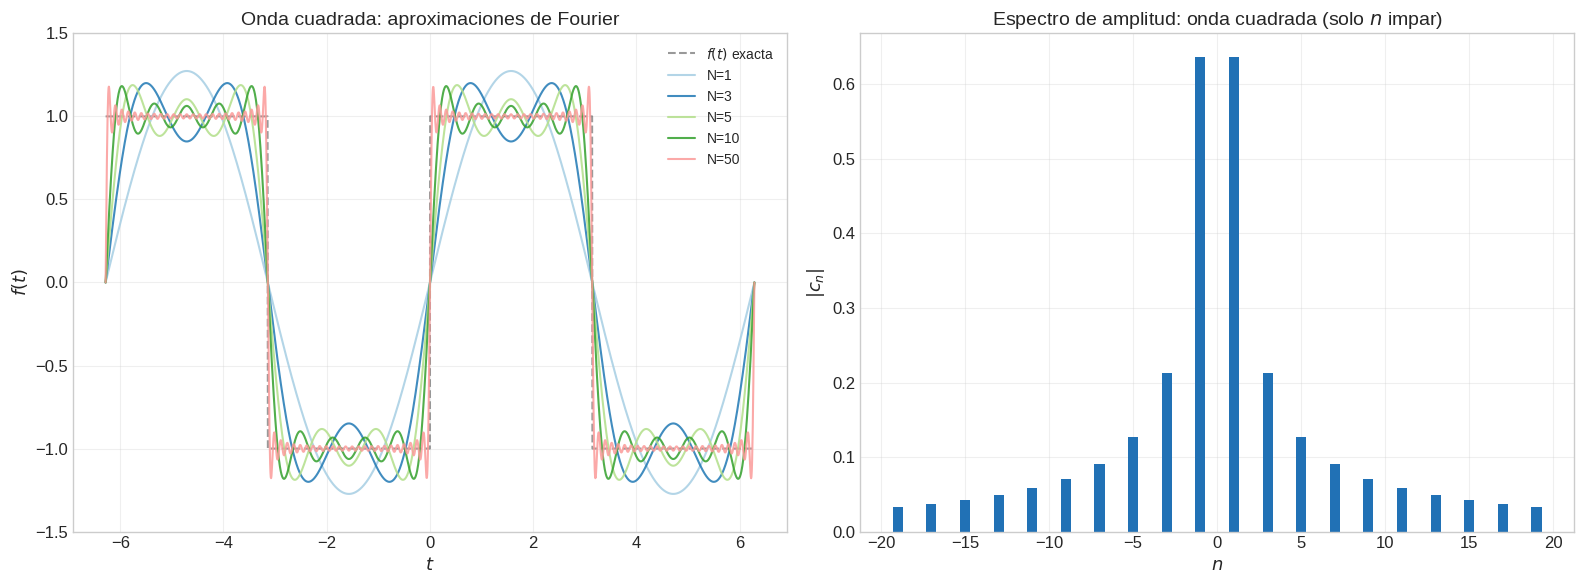

In [2]:
# Onda cuadrada: funcion y aproximaciones de Fourier
def onda_cuadrada(t):
    return np.sign(np.sin(t))

def fourier_cuadrada(t, N):
    resultado = np.zeros_like(t)
    for n in range(1, N + 1, 2):  # Solo impares
        resultado += (4 / (n * np.pi)) * np.sin(n * t)
    return resultado

t = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
Ns = [1, 3, 5, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel izquierdo: aproximaciones
ax = axes[0]
ax.plot(t, onda_cuadrada(t), 'k--', lw=1.5, alpha=0.4, label=r'$f(t)$ exacta')
for i, N in enumerate(Ns):
    ax.plot(t, fourier_cuadrada(t, N), color=COLORES_N[i], lw=1.5,
            label=f'N={N}', alpha=0.85)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$f(t)$')
ax.set_title('Onda cuadrada: aproximaciones de Fourier')
ax.legend(fontsize=10)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)

# Panel derecho: espectro de amplitud |c_n|
ax2 = axes[1]
n_max = 20
ns = np.arange(1, n_max + 1, 2)
cn = 2 / (ns * np.pi)  # |c_n| para onda cuadrada
ax2.bar(ns, cn, color=COLOR_PRINCIPAL, width=0.6, label=r'$|c_n|$')
ax2.bar(-ns, cn, color=COLOR_PRINCIPAL, width=0.6)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$|c_n|$')
ax2.set_title(r'Espectro de amplitud: onda cuadrada (solo $n$ impar)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones de la onda cuadrada:**
- Función **impar** $\to$ solo senos ($a_n = 0$)
- Simetría de media onda $f(t + \pi) = -f(t)$ $\to$ solo armónicos **impares**
- $b_n = \dfrac{4}{n\pi}$ para $n$ impar, $b_n = 0$ para $n$ par
- Decaimiento $\sim 1/n$ (función con saltos) $\to$ convergencia lenta
- Se observa el **fenómeno de Gibbs** en los saltos incluso con $N=50$

### 8.2 Onda triangular

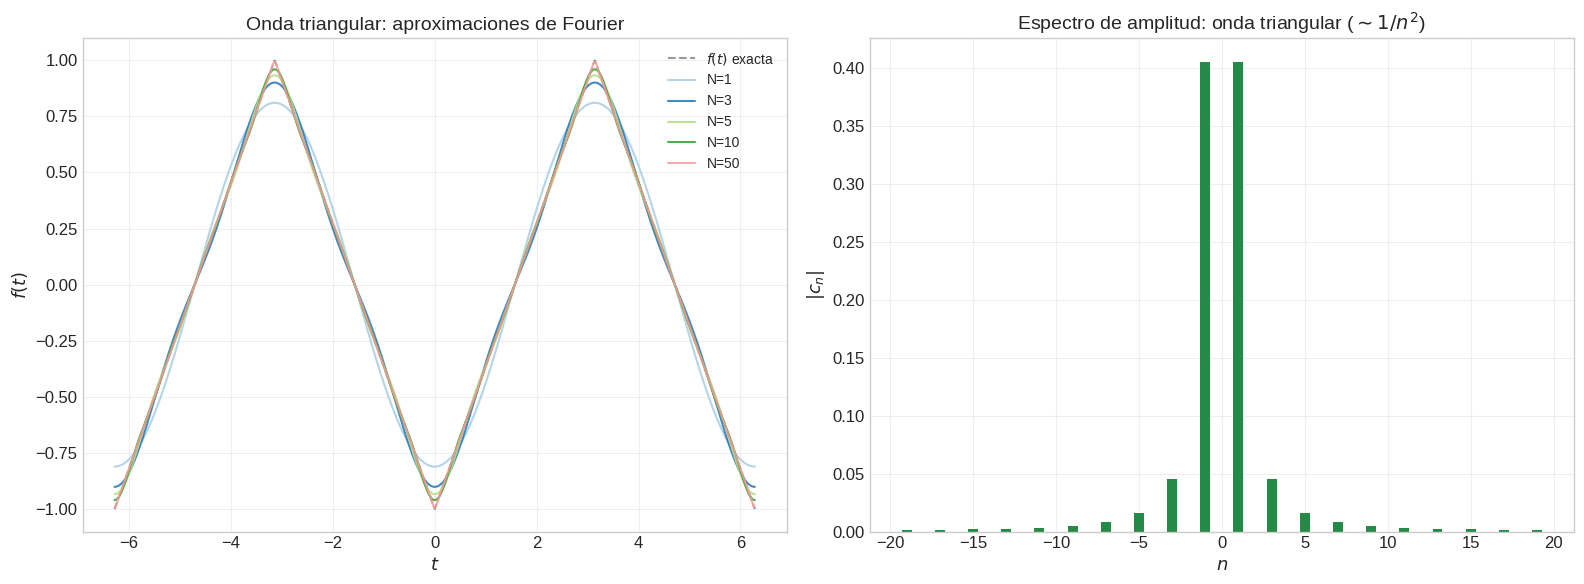

In [3]:
# Onda triangular: funcion y aproximaciones
def onda_triangular(t):
    return 2 * np.abs(2 * (t / (2 * np.pi) - np.floor(t / (2 * np.pi) + 0.5))) - 1

def fourier_triangular_cos(t, N):
    resultado = np.zeros_like(t)
    for n in range(1, N + 1, 2):
        resultado -= (8 / (n**2 * np.pi**2)) * np.cos(n * t)
    return resultado

t = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
Ns = [1, 3, 5, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
f_exact = onda_triangular(t)
ax.plot(t, f_exact, 'k--', lw=1.5, alpha=0.4, label=r'$f(t)$ exacta')
for i, N in enumerate(Ns):
    approx = fourier_triangular_cos(t, N)
    ax.plot(t, approx, color=COLORES_N[i], lw=1.5, label=f'N={N}', alpha=0.85)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$f(t)$')
ax.set_title('Onda triangular: aproximaciones de Fourier')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Espectro
ax2 = axes[1]
n_max = 20
ns = np.arange(1, n_max + 1, 2)
cn = 4 / (ns**2 * np.pi**2)
ax2.bar(ns, cn, color=COLOR_PUNTO, width=0.6, label=r'$|c_n|$')
ax2.bar(-ns, cn, color=COLOR_PUNTO, width=0.6)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$|c_n|$')
ax2.set_title(r'Espectro de amplitud: onda triangular ($\sim 1/n^2$)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones de la onda triangular:**
- Función **par** (versión centrada) $\to$ solo cosenos ($b_n = 0$)
- Simetría de media onda $\to$ solo armónicos **impares**
- $a_n = \dfrac{8}{n^2 \pi^2}$ para $n$ impar
- Decaimiento $\sim 1/n^2$ (función **continua**) $\to$ convergencia **rápida**
- Con solo $N=5$ la aproximación es visualmente excelente (comparar con la cuadrada)

### 8.3 Onda diente de sierra

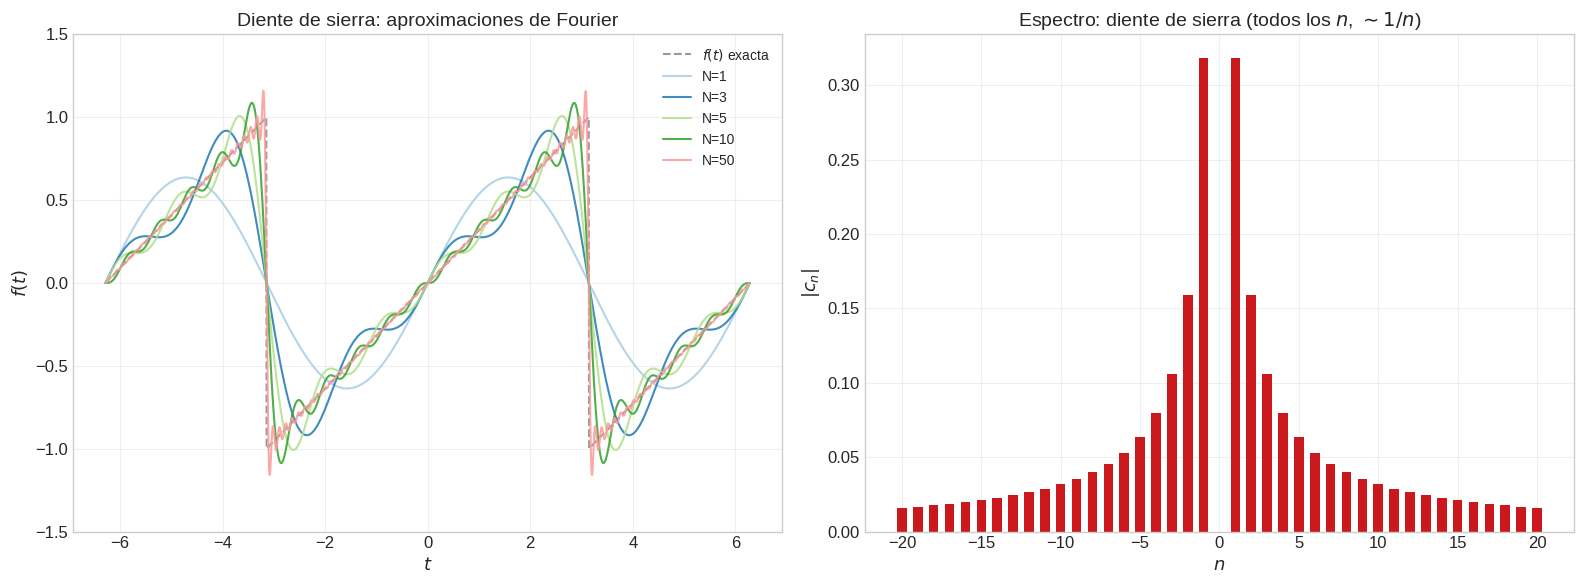

In [4]:
# Onda diente de sierra
def onda_diente(t):
    return 2 * (t / (2 * np.pi) - np.floor(t / (2 * np.pi) + 0.5))

def fourier_diente(t, N):
    resultado = np.zeros_like(t)
    for n in range(1, N + 1):
        resultado += (2 * (-1)**(n + 1) / (n * np.pi)) * np.sin(n * t)
    return resultado

t = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
Ns = [1, 3, 5, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(t, onda_diente(t), 'k--', lw=1.5, alpha=0.4, label=r'$f(t)$ exacta')
for i, N in enumerate(Ns):
    ax.plot(t, fourier_diente(t, N), color=COLORES_N[i], lw=1.5,
            label=f'N={N}', alpha=0.85)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$f(t)$')
ax.set_title(r'Diente de sierra: aproximaciones de Fourier')
ax.legend(fontsize=10)
ax.set_ylim(-1.5, 1.5)
ax.grid(True, alpha=0.3)

# Espectro (tiene todos los armonicos)
ax2 = axes[1]
n_max = 20
ns = np.arange(1, n_max + 1)
cn = 1 / (ns * np.pi)
ax2.bar(ns, cn, color=COLOR_RECTA, width=0.6)
ax2.bar(-ns, cn, color=COLOR_RECTA, width=0.6)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$|c_n|$')
ax2.set_title(r'Espectro: diente de sierra (todos los $n$, $\sim 1/n$)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones del diente de sierra:**
- Función **impar** $\to$ solo senos
- **NO** tiene simetría de media onda $\to$ aparecen **todos** los armónicos
- $b_n = \dfrac{2(-1)^{n+1}}{n\pi}$ para todo $n$
- Decaimiento $\sim 1/n$ (tiene saltos)
- Fenómeno de Gibbs visible en los saltos

### 8.4 Seno medio rectificado

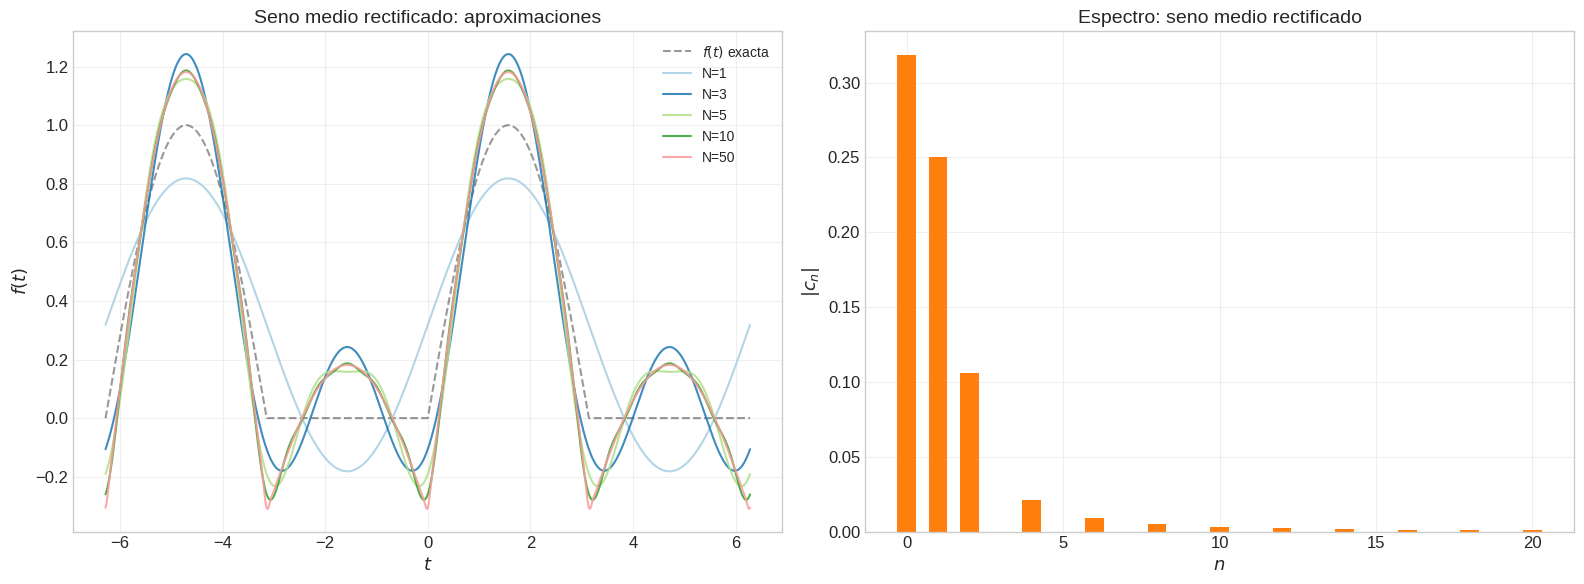

In [5]:
# Seno medio rectificado: f(t) = max(sin(t), 0)
def medio_rectificado(t):
    return np.maximum(np.sin(t), 0)

def fourier_medio_rect(t, N):
    resultado = np.ones_like(t) / np.pi  # a0/2
    resultado += 0.5 * np.sin(t)  # b1*sin(t)
    for n in range(2, N + 1):
        if n % 2 == 0:  # Solo pares tienen a_n != 0
            a_n = (2 / np.pi) * ((-1)**n + 1) / (1 - n**2)
            resultado += a_n * np.cos(n * t)
    return resultado

t = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
Ns = [1, 3, 5, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(t, medio_rectificado(t), 'k--', lw=1.5, alpha=0.4, label=r'$f(t)$ exacta')
for i, N in enumerate(Ns):
    ax.plot(t, fourier_medio_rect(t, N), color=COLORES_N[i], lw=1.5,
            label=f'N={N}', alpha=0.85)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$f(t)$')
ax.set_title(r'Seno medio rectificado: aproximaciones')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Espectro
ax2 = axes[1]
ns_plot = np.arange(0, 21)
cn_vals = []
for n in ns_plot:
    if n == 0:
        cn_vals.append(1 / np.pi)
    elif n == 1:
        cn_vals.append(0.25)
    elif n % 2 == 0:
        cn_vals.append(abs(1 / (np.pi * (1 - n**2))))
    else:
        cn_vals.append(0)
ax2.bar(ns_plot, cn_vals, color=COLOR_AUX1, width=0.6)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$|c_n|$')
ax2.set_title(r'Espectro: seno medio rectificado')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones del seno medio rectificado:**
- Función **ni par ni impar** en general $\to$ tiene **ambos** $a_n$ y $b_n$
- $b_1 = 1/2$ (componente fundamental del seno), $a_n \neq 0$ solo para $n$ par
- La función es **continua** $\to$ decaimiento rápido ($\sim 1/n^2$ para los $a_n$ no nulos)
- Convergencia rápida: con $N=5$ ya es muy buena aproximación

### 8.5 Seno completamente rectificado

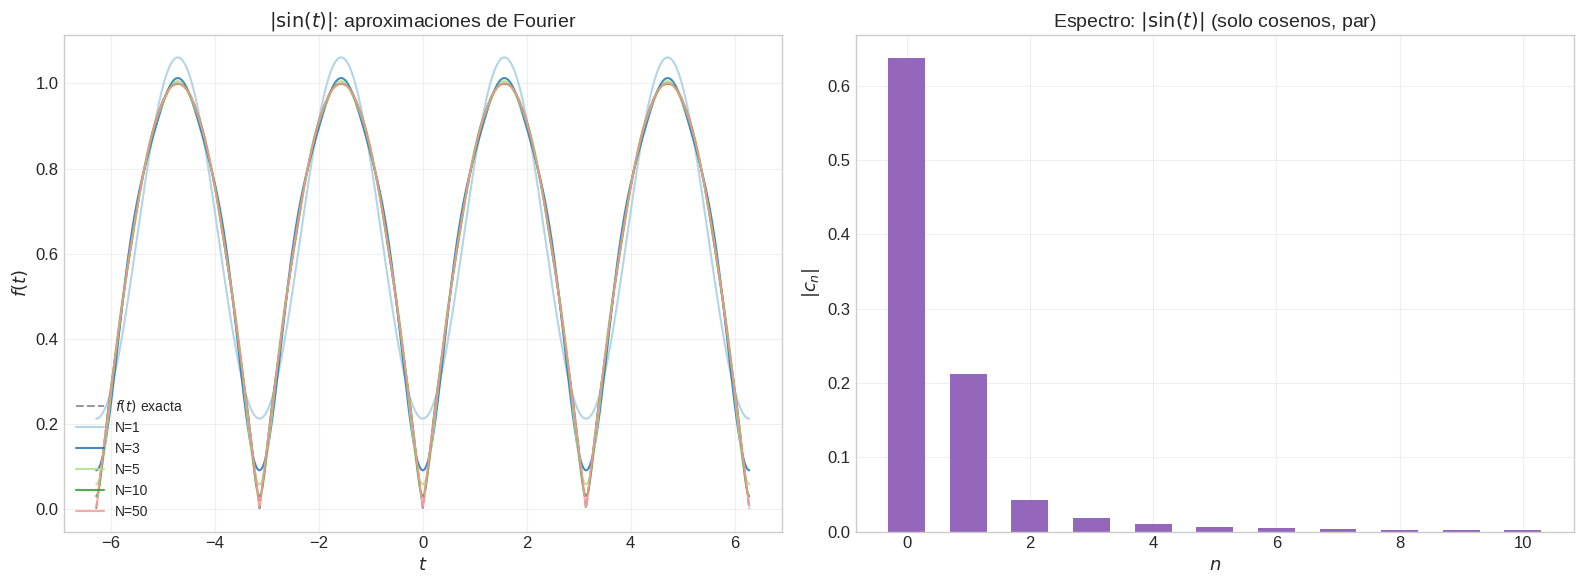

In [6]:
# Seno completamente rectificado: f(t) = |sin(t)|
def completo_rectificado(t):
    return np.abs(np.sin(t))

def fourier_completo_rect(t, N):
    resultado = np.ones_like(t) * 2 / np.pi  # a0/2
    for n in range(1, N + 1):
        a_n = -(4 / np.pi) / (4 * n**2 - 1)
        resultado += a_n * np.cos(2 * n * t)
    return resultado

t = np.linspace(-2 * np.pi, 2 * np.pi, 2000)
Ns = [1, 3, 5, 10, 50]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(t, completo_rectificado(t), 'k--', lw=1.5, alpha=0.4, label=r'$f(t)$ exacta')
for i, N in enumerate(Ns):
    ax.plot(t, fourier_completo_rect(t, N), color=COLORES_N[i], lw=1.5,
            label=f'N={N}', alpha=0.85)
ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$f(t)$')
ax.set_title(r'$|\sin(t)|$: aproximaciones de Fourier')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Espectro
ax2 = axes[1]
ns_plot = np.arange(0, 11)
cn_vals = [2 / np.pi] + [2 / (np.pi * abs(4 * n**2 - 1)) for n in range(1, 11)]
ax2.bar(ns_plot, cn_vals, color=COLOR_AUX2, width=0.6)
ax2.set_xlabel(r'$n$')
ax2.set_ylabel(r'$|c_n|$')
ax2.set_title(r'Espectro: $|\sin(t)|$ (solo cosenos, par)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observaciones de $|\sin(t)|$:**
- Función **par** $\to$ solo cosenos ($b_n = 0$)
- Periodo $\pi$ (la mitad de $2\pi$) $\to$ las frecuencias son $2n$, no $n$
- Función **continua** $\to$ decaimiento $\sim 1/n^2$ $\to$ convergencia muy rápida
- Con $N = 3$ ya es casi indistinguible de la función exacta

### 8.6 Comparación: tasas de decaimiento

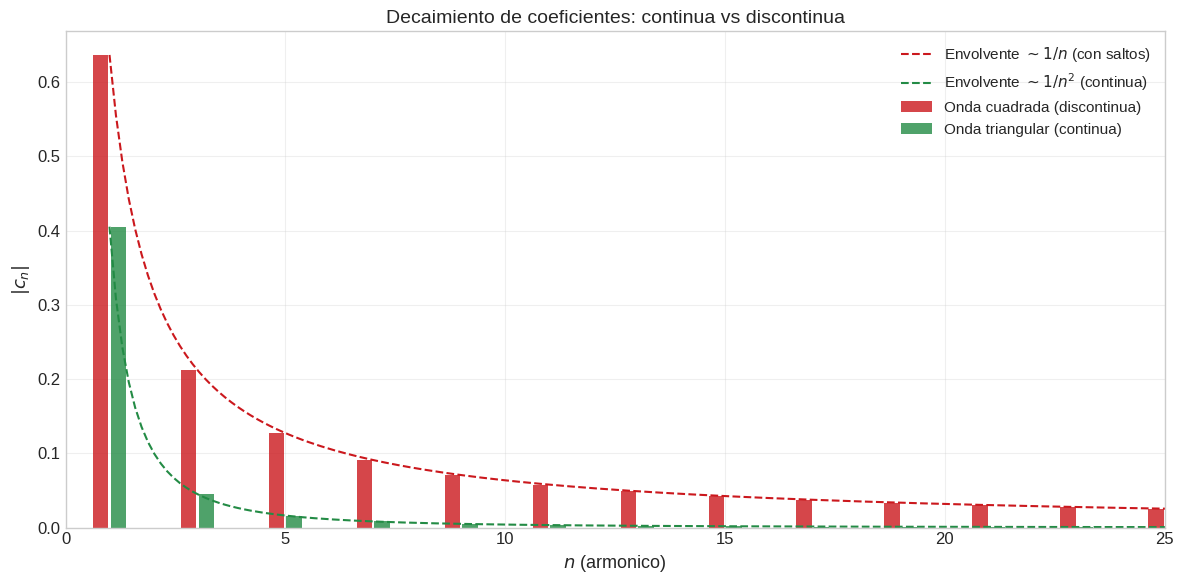

In [7]:
# Comparacion de decaimiento: funcion continua vs discontinua
fig, ax = plt.subplots(figsize=(12, 6))

ns = np.arange(1, 31)

# Onda cuadrada (discontinua): |c_n| ~ 2/(n*pi) para n impar
cn_cuadrada = np.zeros(30)
for i, n in enumerate(ns):
    if n % 2 == 1:
        cn_cuadrada[i] = 2 / (n * np.pi)

# Onda triangular (continua): |c_n| ~ 4/(n^2 * pi^2) para n impar
cn_triangular = np.zeros(30)
for i, n in enumerate(ns):
    if n % 2 == 1:
        cn_triangular[i] = 4 / (n**2 * np.pi**2)

# Envolventes
n_cont = np.linspace(1, 30, 200)
env_1_n = 2 / (n_cont * np.pi)
env_1_n2 = 4 / (n_cont**2 * np.pi**2)

ax.bar(ns - 0.2, cn_cuadrada, width=0.35, color=COLOR_RECTA, alpha=0.8,
       label=r'Onda cuadrada (discontinua)')
ax.bar(ns + 0.2, cn_triangular, width=0.35, color=COLOR_PUNTO, alpha=0.8,
       label=r'Onda triangular (continua)')

ax.plot(n_cont, env_1_n, '--', color=COLOR_RECTA, lw=1.5,
        label=r'Envolvente $\sim 1/n$ (con saltos)')
ax.plot(n_cont, env_1_n2, '--', color=COLOR_PUNTO, lw=1.5,
        label=r'Envolvente $\sim 1/n^2$ (continua)')

ax.set_xlabel(r'$n$ (armonico)')
ax.set_ylabel(r'$|c_n|$')
ax.set_title(r'Decaimiento de coeficientes: continua vs discontinua')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 25)

plt.tight_layout()
plt.show()

**Conclusión clave:**
- Funciones con **saltos**: $|c_n| \sim 1/n$ $\to$ muchos armónicos necesarios
- Funciones **continuas**: $|c_n| \sim 1/n^2$ $\to$ pocos armónicos bastan
- En general: cuanto más **suave** es $f$, más rápido decaen los $|c_n|$
- Regla: si $f$ tiene $k$ derivadas continuas, $|c_n| \sim 1/n^{k+1}$

### 8.7 Detalle del fenómeno de Gibbs

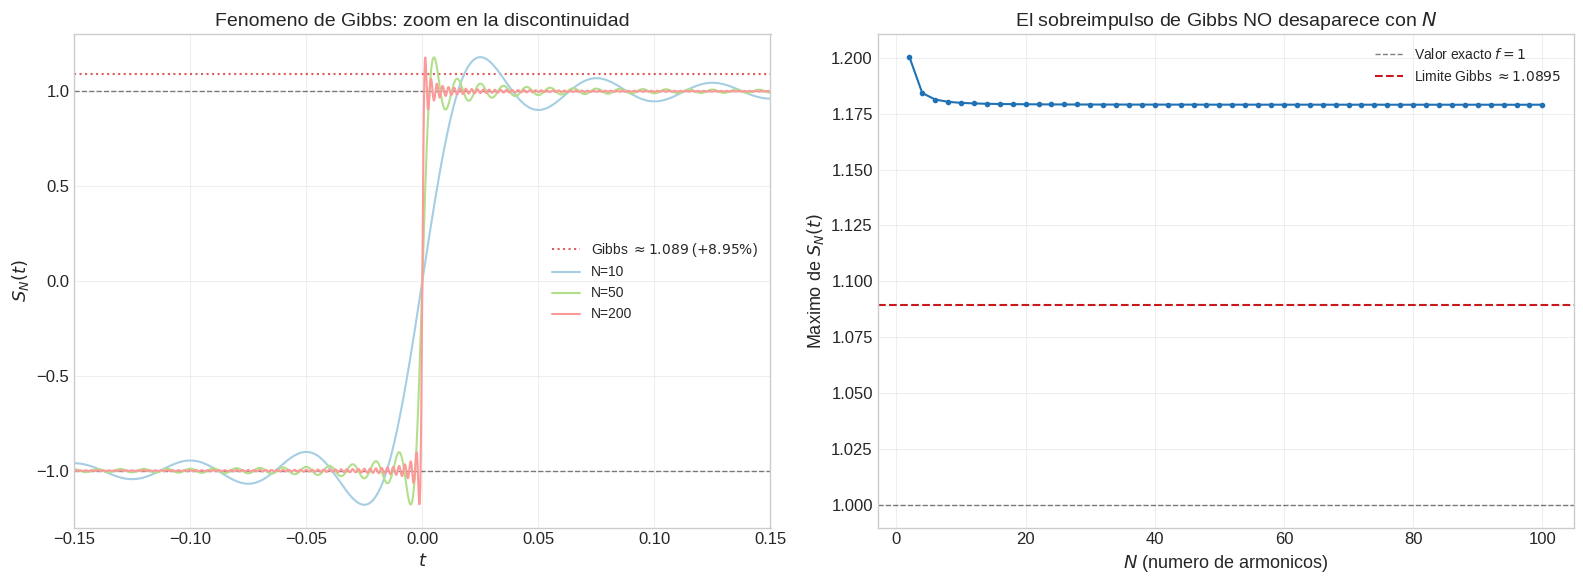

In [8]:
# Detalle del fenomeno de Gibbs en la onda cuadrada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

t = np.linspace(-0.5, 0.5, 5000)

# Panel izquierdo: zoom cerca de la discontinuidad
ax = axes[0]
ax.axhline(y=1, color='k', ls='--', lw=1, alpha=0.5)
ax.axhline(y=-1, color='k', ls='--', lw=1, alpha=0.5)
ax.axhline(y=1.0895, color=COLOR_RECTA, ls=':', lw=1.5, alpha=0.7,
           label=r'Gibbs $\approx 1.089$ ($+8.95\%$)')

for i, N in enumerate([10, 50, 200]):
    approx = np.zeros_like(t)
    for n in range(1, 2 * N, 2):
        approx += (4 / (n * np.pi)) * np.sin(n * 2 * np.pi * t)
    ax.plot(t, approx, color=COLORES_N[2 * i], lw=1.5, label=f'N={N}')

ax.set_xlabel(r'$t$')
ax.set_ylabel(r'$S_N(t)$')
ax.set_title('Fenomeno de Gibbs: zoom en la discontinuidad')
ax.legend(fontsize=10)
ax.set_xlim(-0.15, 0.15)
ax.set_ylim(-1.3, 1.3)
ax.grid(True, alpha=0.3)

# Panel derecho: sobreimpulso vs N
ax2 = axes[1]
Ns_test = np.arange(2, 102, 2)
overshoot = []
for N in Ns_test:
    t_fine = np.linspace(0.0001, 0.3, 10000)
    approx = np.zeros_like(t_fine)
    for n in range(1, 2 * N, 2):
        approx += (4 / (n * np.pi)) * np.sin(n * 2 * np.pi * t_fine)
    overshoot.append(np.max(approx))

ax2.plot(Ns_test, overshoot, 'o-', color=COLOR_PRINCIPAL, ms=3, lw=1.5)
ax2.axhline(y=1.0, color='k', ls='--', lw=1, alpha=0.5, label=r'Valor exacto $f=1$')
ax2.axhline(y=1.0895, color=COLOR_RECTA, ls='--', lw=1.5,
            label=r'Limite Gibbs $\approx 1.0895$')
ax2.set_xlabel(r'$N$ (numero de armonicos)')
ax2.set_ylabel(r'Maximo de $S_N(t)$')
ax2.set_title(r'El sobreimpulso de Gibbs NO desaparece con $N$')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 9. Ejercicios resueltos del boletín

### 9.1 Ejercicio: $f(t) = t^2$ en $[-\pi, \pi]$

**Datos:** $f(t) = t^2$, periodo $2\pi$, $T = 2\pi$, $\omega = 1$.

**Paso 0: Análisis de simetría.** $f(-t) = (-t)^2 = t^2 = f(t)$ $\to$ **función par** $\to$ $b_n = 0$ para todo $n$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi} \int_{-\pi}^{\pi} t^2\, dt$$

Como $t^2$ es par, la integral en $[-\pi, \pi]$ vale el doble de la integral en $[0, \pi]$:

$$a_0 = \frac{1}{\pi} \cdot 2 \int_0^{\pi} t^2\, dt = \frac{2}{\pi} \left[\frac{t^3}{3}\right]_0^{\pi}$$

Evaluando en los límites:

$$a_0 = \frac{2}{\pi} \cdot \frac{\pi^3}{3} = \frac{2\pi^2}{3}$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

Como $f$ es par, usamos la fórmula simplificada:

$$a_n = \frac{2}{\pi} \int_0^{\pi} t^2 \cos(nt)\, dt$$

**Primera integración por partes.** Elegimos:

$$u = t^2, \qquad dv = \cos(nt)\,dt$$
$$du = 2t\,dt, \qquad v = \frac{\sin(nt)}{n}$$

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{\pi} t^2 \cos(nt)\, dt = \left[\frac{t^2 \sin(nt)}{n}\right]_0^{\pi} - \frac{2}{n}\int_0^{\pi} t \sin(nt)\, dt$$

Evaluando el primer término: $\frac{\pi^2 \sin(n\pi)}{n} - 0 = 0$ (porque $\sin(n\pi) = 0$ para todo entero $n$).

Queda:

$$\int_0^{\pi} t^2 \cos(nt)\, dt = -\frac{2}{n}\int_0^{\pi} t \sin(nt)\, dt$$

**Segunda integración por partes.** Para $\int_0^{\pi} t \sin(nt)\,dt$, elegimos:

$$u = t, \qquad dv = \sin(nt)\,dt$$
$$du = dt, \qquad v = -\frac{\cos(nt)}{n}$$

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{\pi} t \sin(nt)\, dt = \left[-\frac{t\cos(nt)}{n}\right]_0^{\pi} + \frac{1}{n}\int_0^{\pi}\cos(nt)\,dt$$

Evaluando el primer término:

$$-\frac{\pi\cos(n\pi)}{n} - \left(-\frac{0 \cdot \cos(0)}{n}\right) = -\frac{\pi\cos(n\pi)}{n} = -\frac{\pi(-1)^n}{n}$$

(usando que $\cos(n\pi) = (-1)^n$).

Evaluando el segundo término:

$$\frac{1}{n}\left[\frac{\sin(nt)}{n}\right]_0^{\pi} = \frac{1}{n}\cdot\frac{\sin(n\pi) - \sin(0)}{n} = \frac{0}{n^2} = 0$$

(porque $\sin(n\pi) = 0$ para todo entero $n$).

Así:

$$\int_0^{\pi} t \sin(nt)\, dt = -\frac{\pi(-1)^n}{n}$$

**Sustituyendo** en la expresión original:

$$\int_0^{\pi} t^2 \cos(nt)\, dt = -\frac{2}{n}\cdot\left(-\frac{\pi(-1)^n}{n}\right) = \frac{2\pi(-1)^n}{n^2}$$

Por tanto:

$$a_n = \frac{2}{\pi} \cdot \frac{2\pi(-1)^n}{n^2} = \frac{4(-1)^n}{n^2}$$

$$\boxed{a_n = \frac{4(-1)^n}{n^2}}$$

---

**Resultado final:**

$$\boxed{f(t) = t^2 \sim \frac{\pi^2}{3} + \sum_{n=1}^{\infty} \frac{4(-1)^n}{n^2} \cos(nt)}$$

---

**Aplicación: deducción de series numéricas**

Evaluando en $t = 0$ (punto de continuidad, $f(0) = 0$):

$$0 = \frac{\pi^2}{3} + 4\sum_{n=1}^{\infty} \frac{(-1)^n}{n^2}$$

$$4\sum_{n=1}^{\infty} \frac{(-1)^n}{n^2} = -\frac{\pi^2}{3} \implies \sum_{n=1}^{\infty} \frac{(-1)^n}{n^2} = -\frac{\pi^2}{12}$$

Cambiando signo: $\boxed{\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n^2} = \frac{\pi^2}{12}}$

Evaluando en $t = \pi$ (punto de continuidad, $f(\pi) = \pi^2$):

$$\pi^2 = \frac{\pi^2}{3} + 4\sum_{n=1}^{\infty} \frac{(-1)^n \cos(n\pi)}{n^2} = \frac{\pi^2}{3} + 4\sum_{n=1}^{\infty} \frac{(-1)^n \cdot (-1)^n}{n^2} = \frac{\pi^2}{3} + 4\sum_{n=1}^{\infty} \frac{1}{n^2}$$

$$4\sum_{n=1}^{\infty}\frac{1}{n^2} = \pi^2 - \frac{\pi^2}{3} = \frac{2\pi^2}{3}$$

$$\boxed{\sum_{n=1}^{\infty} \frac{1}{n^2} = \frac{\pi^2}{6}}$$

### 9.2 Ejercicio: $f(t) = |\sin t|$ en $[-\pi, \pi]$

**Datos:** $f(t) = |\sin t|$, periodo $\pi$ (pero la pedimos como serie de periodo $2\pi$).

**Paso 0: Simetría.** $f(-t) = |\sin(-t)| = |\sin t| = f(t)$ $\to$ **función par** $\to$ $b_n = 0$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi} \int_{-\pi}^{\pi} |\sin t|\, dt$$

Como $|\sin t|$ es par, doblamos la integral en $[0, \pi]$, donde $|\sin t| = \sin t \geq 0$:

$$a_0 = \frac{2}{\pi} \int_0^{\pi} \sin t\, dt = \frac{2}{\pi} \left[-\cos t\right]_0^{\pi}$$

Evaluando en los límites:

$$a_0 = \frac{2}{\pi}\left[-\cos(\pi) - (-\cos(0))\right] = \frac{2}{\pi}\left[-(-1) + 1\right] = \frac{2}{\pi}(1 + 1) = \frac{4}{\pi}$$

---

**Paso 2: Calcular $a_n$** ($n \geq 1$)

$$a_n = \frac{2}{\pi} \int_0^{\pi} \sin t \cos(nt)\, dt$$

**Aplicamos la identidad producto-a-suma:**

$$\sin A \cos B = \frac{1}{2}[\sin(A+B) + \sin(A-B)]$$

Con $A = t$, $B = nt$:

$$\sin t \cos(nt) = \frac{1}{2}[\sin((1+n)t) + \sin((1-n)t)]$$

Sustituyendo:

$$a_n = \frac{1}{\pi} \int_0^{\pi} [\sin((1+n)t) + \sin((1-n)t)]\, dt$$

---

**Caso $n = 1$:**

$$a_1 = \frac{1}{\pi}\int_0^{\pi}[\sin(2t) + \sin(0)]\,dt = \frac{1}{\pi}\int_0^{\pi}\sin(2t)\,dt$$

$$= \frac{1}{\pi}\left[-\frac{\cos(2t)}{2}\right]_0^{\pi} = \frac{1}{\pi}\left[-\frac{\cos(2\pi)}{2} + \frac{\cos(0)}{2}\right] = \frac{1}{\pi}\left[-\frac{1}{2} + \frac{1}{2}\right] = 0$$

---

**Caso $n \neq 1$, $n \geq 2$:**

$$a_n = \frac{1}{\pi}\left[-\frac{\cos((1+n)t)}{1+n} - \frac{\cos((1-n)t)}{1-n}\right]_0^{\pi}$$

Evaluando en $t = \pi$:

$$-\frac{\cos((1+n)\pi)}{1+n} - \frac{\cos((1-n)\pi)}{1-n}$$

Evaluando en $t = 0$:

$$-\frac{\cos(0)}{1+n} - \frac{\cos(0)}{1-n} = -\frac{1}{1+n} - \frac{1}{1-n}$$

Restando (valor en $\pi$ menos valor en $0$):

$$a_n = \frac{1}{\pi}\left[\frac{1 - \cos((1+n)\pi)}{1+n} + \frac{1 - \cos((1-n)\pi)}{1-n}\right]$$

**Simplificando $\cos((1+n)\pi)$ y $\cos((1-n)\pi)$:**

$$\cos((1+n)\pi) = (-1)^{1+n} = (-1)^{n+1}$$
$$\cos((1-n)\pi) = (-1)^{1-n} = (-1)^{1-n}$$

Observamos que $(-1)^{1-n} = (-1)^1 \cdot (-1)^{-n} = -(-1)^{-n} = -\frac{1}{(-1)^n} = -(-1)^{-n}$, pero es mas facil notar que $(-1)^{1-n} = (-1)^{1+n}$ (porque $(-1)^{-2n} = 1$). Entonces:

$$\cos((1+n)\pi) = \cos((1-n)\pi) = (-1)^{n+1}$$

Sustituyendo:

$$a_n = \frac{1 - (-1)^{n+1}}{\pi}\left[\frac{1}{1+n} + \frac{1}{1-n}\right]$$

Para la suma de fracciones:

$$\frac{1}{1+n} + \frac{1}{1-n} = \frac{(1-n) + (1+n)}{(1+n)(1-n)} = \frac{2}{1 - n^2} = \frac{-2}{n^2 - 1}$$

Además, $1 - (-1)^{n+1} = 1 + (-1)^n$, entonces:

$$a_n = \frac{(1 + (-1)^n)}{\pi} \cdot \frac{-2}{n^2 - 1}$$

---

**Para $n$ impar:** $(-1)^n = -1$, luego $1 + (-1)^n = 0$, asi que $a_n = 0$.

**Para $n$ par ($n = 2k$):** $(-1)^n = 1$, luego $1 + (-1)^n = 2$:

$$a_{2k} = \frac{2}{\pi} \cdot \frac{-2}{(2k)^2 - 1} = \frac{-4}{\pi(4k^2 - 1)}$$

---

**Resultado final:**

Usando $a_0/2 = 2/\pi$:

$$\boxed{|\sin t| = \frac{2}{\pi} - \frac{4}{\pi}\sum_{k=1}^{\infty} \frac{\cos(2kt)}{4k^2 - 1}}$$

Escribiendo los primeros terminos: $|\sin t| = \frac{2}{\pi} - \frac{4}{\pi}\left(\frac{\cos 2t}{3} + \frac{\cos 4t}{15} + \frac{\cos 6t}{35} + \cdots\right)$

### 9.3 Ejercicio: $f(t) = t \cos t$ en $[-\pi, \pi]$

**Datos:** $f(t) = t \cos t$, periodo $2\pi$.

**Paso 0: Simetría.** $f(-t) = (-t)\cos(-t) = -t\cos t = -f(t)$ $\to$ **función impar** $\to$ $a_n = 0$, $a_0 = 0$.

---

**Paso 1: Calcular $b_n$**

$$b_n = \frac{1}{\pi} \int_{-\pi}^{\pi} t \cos t \sin(nt)\, dt$$

Como $t\cos t$ es impar y $\sin(nt)$ es impar, su producto es par. Entonces:

$$b_n = \frac{2}{\pi} \int_0^{\pi} t \cos t \sin(nt)\, dt$$

**Aplicamos la identidad producto-a-suma:**

$$\cos A \sin B = \frac{1}{2}[\sin(A+B) - \sin(A-B)]$$

Con $A = t$, $B = nt$:

$$\cos t \sin(nt) = \frac{1}{2}[\sin((n+1)t) - \sin((n-1)t)]$$

Sustituyendo:

$$b_n = \frac{1}{\pi} \int_0^{\pi} t[\sin((n+1)t) - \sin((n-1)t)]\, dt$$

---

**Lema auxiliar: $\int_0^{\pi} t \sin(mt)\,dt$ para entero $m \neq 0$**

Integramos por partes con $u = t$, $dv = \sin(mt)\,dt$:

$$du = dt, \qquad v = -\frac{\cos(mt)}{m}$$

$$\int_0^{\pi} t \sin(mt)\,dt = \left[-\frac{t\cos(mt)}{m}\right]_0^{\pi} + \frac{1}{m}\int_0^{\pi}\cos(mt)\,dt$$

Primer termino: $-\frac{\pi\cos(m\pi)}{m} - 0 = -\frac{\pi(-1)^m}{m}$

Segundo termino: $\frac{1}{m}\left[\frac{\sin(mt)}{m}\right]_0^{\pi} = \frac{\sin(m\pi) - 0}{m^2} = 0$

$$\boxed{\int_0^{\pi} t \sin(mt)\,dt = -\frac{\pi(-1)^m}{m}}$$

---

**Caso $n = 1$:**

Para $n = 1$: $\sin((n+1)t) = \sin(2t)$ y $\sin((n-1)t) = \sin(0) = 0$:

$$b_1 = \frac{1}{\pi}\int_0^{\pi} t \sin(2t)\,dt$$

Aplicando el lema con $m = 2$:

$$b_1 = \frac{1}{\pi}\cdot\left(-\frac{\pi(-1)^2}{2}\right) = \frac{1}{\pi}\cdot\left(-\frac{\pi}{2}\right) = -\frac{1}{2}$$

---

**Caso $n \geq 2$ ($n \neq 1$):**

$$b_n = \frac{1}{\pi}\left[\int_0^{\pi} t\sin((n+1)t)\,dt - \int_0^{\pi} t\sin((n-1)t)\,dt\right]$$

Aplicando el lema con $m = n+1$ y $m = n-1$:

$$b_n = \frac{1}{\pi}\left[-\frac{\pi(-1)^{n+1}}{n+1} - \left(-\frac{\pi(-1)^{n-1}}{n-1}\right)\right]$$

$$= \frac{1}{\pi}\left[-\frac{\pi(-1)^{n+1}}{n+1} + \frac{\pi(-1)^{n-1}}{n-1}\right]$$

Factorizando $\pi$:

$$= -\frac{(-1)^{n+1}}{n+1} + \frac{(-1)^{n-1}}{n-1}$$

Observamos que $(-1)^{n-1} = (-1)^{n+1} \cdot (-1)^{-2} = (-1)^{n+1}$ (pues $(-1)^{-2} = 1$). Entonces:

$$b_n = (-1)^{n+1}\left[-\frac{1}{n+1} + \frac{1}{n-1}\right]$$

Calculando la diferencia de fracciones:

$$\frac{1}{n-1} - \frac{1}{n+1} = \frac{(n+1) - (n-1)}{(n-1)(n+1)} = \frac{2}{n^2 - 1}$$

Por tanto:

$$\boxed{b_n = \frac{2(-1)^{n+1}}{n^2 - 1}, \qquad n \geq 2}$$

---

**Resultado final:**

$$\boxed{t\cos t \sim -\frac{1}{2}\sin t + 2\sum_{n=2}^{\infty} \frac{(-1)^{n+1}}{n^2 - 1}\sin(nt)}$$

Primeros terminos: $t\cos t \sim -\frac{1}{2}\sin t + \frac{2}{3}\sin(2t) - \frac{2}{8}\sin(3t) + \frac{2}{15}\sin(4t) - \cdots$

### 9.4 Ejercicio: Pulso rectangular y deducción de serie

**Datos:** $f(t) = 1$ para $|t| < d$ y $f(t) = 0$ para $d < |t| < \pi$, con $0 < d < \pi$. Periodo $2\pi$.

**Paso 0: Simetría.** $f(-t) = f(t)$ (la condicion solo depende de $|t|$) $\to$ **función par** $\to$ $b_n = 0$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi}\int_{-\pi}^{\pi} f(t)\,dt$$

Como $f(t) = 0$ fuera de $[-d, d]$ y $f(t) = 1$ dentro:

$$a_0 = \frac{1}{\pi}\int_{-d}^{d} 1\,dt = \frac{1}{\pi}\left[t\right]_{-d}^{d} = \frac{1}{\pi}(d - (-d)) = \frac{2d}{\pi}$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

Como $f$ es par:

$$a_n = \frac{2}{\pi}\int_0^{\pi} f(t)\cos(nt)\,dt$$

Pero $f(t) = 1$ solo en $[0, d]$ y $f(t) = 0$ en $(d, \pi]$:

$$a_n = \frac{2}{\pi}\int_0^{d} 1 \cdot \cos(nt)\,dt$$

Integrando directamente:

$$a_n = \frac{2}{\pi}\left[\frac{\sin(nt)}{n}\right]_0^{d}$$

Evaluando en los limites:

$$a_n = \frac{2}{\pi}\left[\frac{\sin(nd)}{n} - \frac{\sin(0)}{n}\right] = \frac{2}{\pi}\cdot\frac{\sin(nd)}{n}$$

$$\boxed{a_n = \frac{2\sin(nd)}{n\pi}}$$

---

**Resultado final:**

Usando $a_0/2 = d/\pi$:

$$\boxed{f(t) = \frac{d}{\pi} + \frac{2}{\pi}\sum_{n=1}^{\infty} \frac{\sin(nd)}{n}\cos(nt)}$$

---

**Deducción de una serie numérica**

Evaluamos la serie en $t = 0$. En $t = 0$, $f(0) = 1$ (punto de continuidad, ya que $0 < d$), y $\cos(n \cdot 0) = 1$:

$$f(0) = 1 = \frac{d}{\pi} + \frac{2}{\pi}\sum_{n=1}^{\infty} \frac{\sin(nd)}{n}$$

Despejando la suma:

$$\frac{2}{\pi}\sum_{n=1}^{\infty} \frac{\sin(nd)}{n} = 1 - \frac{d}{\pi} = \frac{\pi - d}{\pi}$$

$$\boxed{\sum_{n=1}^{\infty} \frac{\sin(nd)}{n} = \frac{\pi - d}{2}}$$

Esta identidad es valida para $0 < d < \pi$. Para $d = \pi/2$ da $\sum \frac{\sin(n\pi/2)}{n} = \frac{\pi}{4}$, que se reduce a $1 - \frac{1}{3} + \frac{1}{5} - \cdots = \frac{\pi}{4}$ (serie de Leibniz).

### 9.5 Ejercicio: $f(t) = t^2$ en distintos intervalos y como serie de senos/cosenos

**Caso A: Serie de cosenos de $f(t) = t^2$ en $[0, \pi]$**

La extensión par de $t^2$ en $[0, \pi]$ es $f(-t) = (-t)^2 = t^2 = f(t)$, es decir, la misma funcion $t^2$ en $[-\pi, \pi]$. Por tanto coincide con la serie completa ya calculada en el Ejercicio 9.1:

$$t^2 \sim \frac{\pi^2}{3} + 4\sum_{n=1}^{\infty} \frac{(-1)^n}{n^2}\cos(nt), \qquad t \in [0, \pi]$$

---

**Caso B: Serie de senos de $f(t) = t^2$ en $[0, \pi]$**

Ahora realizamos la extensión impar: definimos $g(t) = t^2$ en $(0, \pi)$ y $g(-t) = -g(t)$. Calculamos:

$$b_n = \frac{2}{\pi}\int_0^{\pi} t^2 \sin(nt)\,dt$$

**Primera integración por partes.** Elegimos:

$$u = t^2, \qquad dv = \sin(nt)\,dt$$
$$du = 2t\,dt, \qquad v = -\frac{\cos(nt)}{n}$$

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{\pi} t^2 \sin(nt)\,dt = \left[-\frac{t^2\cos(nt)}{n}\right]_0^{\pi} + \frac{2}{n}\int_0^{\pi} t\cos(nt)\,dt$$

Evaluando el primer término:

$$-\frac{\pi^2\cos(n\pi)}{n} - \left(-\frac{0}{n}\right) = -\frac{\pi^2(-1)^n}{n}$$

---

**Segunda integración por partes.** Para $\int_0^{\pi} t\cos(nt)\,dt$, elegimos:

$$u = t, \qquad dv = \cos(nt)\,dt$$
$$du = dt, \qquad v = \frac{\sin(nt)}{n}$$

$$\int_0^{\pi} t\cos(nt)\,dt = \left[\frac{t\sin(nt)}{n}\right]_0^{\pi} - \frac{1}{n}\int_0^{\pi}\sin(nt)\,dt$$

Primer termino: $\frac{\pi\sin(n\pi)}{n} - 0 = 0$ (ya que $\sin(n\pi) = 0$).

Segundo termino:

$$-\frac{1}{n}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi} = \frac{1}{n^2}\left[\cos(nt)\right]_0^{\pi} = \frac{1}{n^2}\left[\cos(n\pi) - \cos(0)\right] = \frac{(-1)^n - 1}{n^2}$$

Así:

$$\int_0^{\pi} t\cos(nt)\,dt = \frac{(-1)^n - 1}{n^2}$$

---

**Sustituyendo** en la expresión de la primera integración por partes:

$$\int_0^{\pi} t^2 \sin(nt)\,dt = -\frac{\pi^2(-1)^n}{n} + \frac{2}{n}\cdot\frac{(-1)^n - 1}{n^2}$$

$$= -\frac{\pi^2(-1)^n}{n} + \frac{2[(-1)^n - 1]}{n^3}$$

Por tanto:

$$b_n = \frac{2}{\pi}\left[-\frac{\pi^2(-1)^n}{n} + \frac{2[(-1)^n - 1]}{n^3}\right]$$

Separando los terminos:

$$\boxed{b_n = -\frac{2\pi(-1)^n}{n} + \frac{4[(-1)^n - 1]}{\pi n^3}}$$

**Para $n$ par** ($(-1)^n = 1$): $b_n = -\frac{2\pi}{n} + 0 = -\frac{2\pi}{n}$

**Para $n$ impar** ($(-1)^n = -1$): $b_n = \frac{2\pi}{n} + \frac{4(-2)}{\pi n^3} = \frac{2\pi}{n} - \frac{8}{\pi n^3}$

---

**Resultado final:**

$$t^2 \sim \sum_{n=1}^{\infty} b_n \sin(nt), \qquad t \in (0, \pi)$$

**Nota importante sobre la convergencia:** En $t = 0$ y $t = \pi$, la serie converge a $0$ (promedio de los limites laterales de la extensión impar), NO a $f(0) = 0$ ni a $f(\pi) = \pi^2$. En $t = 0$ coincide por casualidad ($f(0) = 0$), pero en $t = \pi$ la serie da $0$ mientras que $f(\pi) = \pi^2$.

### 9.6 Ejercicio: $f(t) = 0$ para $t < 0$, $f(t) = \sin t$ para $t \geq 0$, en $[-\pi, \pi]$

**Datos:** Función a trozos, periodo $2\pi$.

$$f(t) = \begin{cases} 0 & -\pi \leq t < 0 \\ \sin t & 0 \leq t \leq \pi \end{cases}$$

**Paso 0: Análisis de simetría.** $f(-\pi/2) = 0$ pero $f(\pi/2) = \sin(\pi/2) = 1$, asi que $f(-t) \neq f(t)$ y $f(-t) \neq -f(t)$ $\to$ **NO es ni par ni impar** $\to$ calcular $a_n$ y $b_n$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi}\int_{-\pi}^{\pi} f(t)\,dt = \frac{1}{\pi}\left[\int_{-\pi}^{0} 0\,dt + \int_0^{\pi} \sin t\,dt\right]$$

$$= \frac{1}{\pi}\int_0^{\pi} \sin t\,dt = \frac{1}{\pi}\left[-\cos t\right]_0^{\pi}$$

Evaluando en los limites:

$$a_0 = \frac{1}{\pi}\left[-\cos(\pi) - (-\cos(0))\right] = \frac{1}{\pi}\left[1 + 1\right] = \frac{2}{\pi}$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{1}{\pi}\int_{-\pi}^{\pi} f(t)\cos(nt)\,dt = \frac{1}{\pi}\int_0^{\pi} \sin t \cos(nt)\,dt$$

**Aplicamos la identidad producto-a-suma:**

$$\sin t \cos(nt) = \frac{1}{2}[\sin((1+n)t) + \sin((1-n)t)]$$

$$a_n = \frac{1}{2\pi}\int_0^{\pi}[\sin((1+n)t) + \sin((1-n)t)]\,dt$$

---

**Caso $n = 1$:**

$$a_1 = \frac{1}{2\pi}\int_0^{\pi}[\sin(2t) + \sin(0)]\,dt = \frac{1}{2\pi}\int_0^{\pi}\sin(2t)\,dt$$

$$= \frac{1}{2\pi}\left[-\frac{\cos(2t)}{2}\right]_0^{\pi} = \frac{1}{2\pi}\left[-\frac{\cos(2\pi)}{2} + \frac{\cos(0)}{2}\right] = \frac{1}{2\pi}\left[-\frac{1}{2} + \frac{1}{2}\right] = 0$$

---

**Caso $n \geq 2$:**

$$a_n = \frac{1}{2\pi}\left[-\frac{\cos((1+n)t)}{1+n} + \frac{\cos((n-1)t)}{n-1}\right]_0^{\pi}$$

Nota: usamos $\sin((1-n)t) = -\sin((n-1)t)$, cuya primitiva es $\frac{\cos((n-1)t)}{n-1}$.

Evaluando en $t = \pi$:

$$-\frac{\cos((1+n)\pi)}{1+n} + \frac{\cos((n-1)\pi)}{n-1} = -\frac{(-1)^{n+1}}{1+n} + \frac{(-1)^{n-1}}{n-1}$$

Como $(-1)^{n+1} = (-1)^{n-1}$ (difieren en exponente $2$), llamemos $\alpha = (-1)^{n+1}$:

Valor en $\pi$: $-\frac{\alpha}{1+n} + \frac{\alpha}{n-1} = \alpha\left(\frac{1}{n-1} - \frac{1}{n+1}\right) = \alpha\cdot\frac{2}{n^2-1}$

Evaluando en $t = 0$:

$$-\frac{1}{1+n} + \frac{1}{n-1} = \frac{2}{n^2-1}$$

Restando:

$$a_n = \frac{1}{2\pi}\left[\alpha\cdot\frac{2}{n^2-1} - \frac{2}{n^2-1}\right] = \frac{1}{2\pi}\cdot\frac{2}{n^2-1}(\alpha - 1) = \frac{(-1)^{n+1} - 1}{\pi(n^2-1)}$$

Reescribiendo: $(-1)^{n+1} - 1 = -(1 + (-1)^n)$ (verificar: si $n$ par, $(-1)^{n+1}-1 = -1-1 = -2$ y $-(1+1) = -2$; si $n$ impar, $1-1=0$ y $-(1-1)=0$).

$$a_n = \frac{-(1 + (-1)^n)}{\pi(n^2 - 1)}$$

**Para $n$ impar:** $1 + (-1)^n = 0 \to a_n = 0$.

**Para $n$ par:** $1 + (-1)^n = 2 \to a_n = \dfrac{-2}{\pi(n^2-1)}$.

---

**Paso 3: Calcular $b_n$**

$$b_n = \frac{1}{\pi}\int_0^{\pi} \sin t \sin(nt)\,dt$$

**Aplicamos la identidad:**

$$\sin A \sin B = \frac{1}{2}[\cos(A-B) - \cos(A+B)]$$

$$b_n = \frac{1}{2\pi}\int_0^{\pi}[\cos((1-n)t) - \cos((1+n)t)]\,dt$$

---

**Caso $n = 1$:**

$$b_1 = \frac{1}{2\pi}\int_0^{\pi}[\cos(0) - \cos(2t)]\,dt = \frac{1}{2\pi}\int_0^{\pi}\left[1 - \cos(2t)\right]\,dt$$

$$= \frac{1}{2\pi}\left[t - \frac{\sin(2t)}{2}\right]_0^{\pi} = \frac{1}{2\pi}\left[\pi - 0 - 0 + 0\right] = \frac{1}{2}$$

---

**Caso $n \geq 2$:**

$$b_n = \frac{1}{2\pi}\left[\frac{\sin((1-n)t)}{1-n} - \frac{\sin((1+n)t)}{1+n}\right]_0^{\pi}$$

En $t = \pi$: $\frac{\sin((1-n)\pi)}{1-n} - \frac{\sin((1+n)\pi)}{1+n}$. Ambos senos son $\sin(m\pi) = 0$ para entero $m$.

En $t = 0$: ambos senos son $0$.

$$b_n = \frac{1}{2\pi}(0 - 0) = 0 \quad \text{para } n \geq 2$$

---

**Resultado final:**

Recopilando: $a_0 = 2/\pi$, $a_1 = 0$, $a_n = -2/[\pi(n^2-1)]$ para $n$ par $\geq 2$ (cero para impar), $b_1 = 1/2$, $b_n = 0$ para $n \geq 2$.

Reindexando los terminos pares $n = 2k$:

$$\boxed{f(t) \sim \frac{1}{\pi} + \frac{1}{2}\sin t - \frac{2}{\pi}\sum_{k=1}^{\infty}\frac{\cos(2kt)}{4k^2 - 1}}$$

Primeros terminos: $f(t) \sim \frac{1}{\pi} + \frac{1}{2}\sin t - \frac{2}{3\pi}\cos(2t) - \frac{2}{15\pi}\cos(4t) - \cdots$

---

**Convergencia en $t = 0$:** la serie converge a $\frac{f(0^+) + f(0^-)}{2} = \frac{\sin(0) + 0}{2} = \frac{0 + 0}{2} = 0$ (coincide con $f(0) = 0$ pues $f$ es continua en $0$, aunque la funcion tiene definiciones distintas a cada lado).

### 9.7 Ejercicio: $f(t) = 1 - \cos^2 t$

**Datos:** $f(t) = 1 - \cos^2 t$.

**Paso 0: Simplificar primero usando identidades trigonométricas.**

Recordamos la identidad del angulo doble:

$$\cos^2 t = \frac{1 + \cos(2t)}{2}$$

Sustituyendo en $f(t)$:

$$f(t) = 1 - \frac{1 + \cos(2t)}{2} = 1 - \frac{1}{2} - \frac{\cos(2t)}{2} = \frac{1}{2} - \frac{\cos(2t)}{2}$$

---

**Paso 1: Reconocer que ya es una serie de Fourier.**

La expresión $f(t) = \frac{1}{2} - \frac{1}{2}\cos(2t)$ ya tiene la forma de una serie de Fourier finita:

$$f(t) = \frac{a_0}{2} + \sum_{n=1}^{\infty} [a_n \cos(nt) + b_n \sin(nt)]$$

Comparando termino a termino:

- $\frac{a_0}{2} = \frac{1}{2}$, luego $a_0 = 1$
- $a_1 = 0$ (no hay termino $\cos(t)$)
- $a_2 = -\frac{1}{2}$ (el coeficiente de $\cos(2t)$)
- $a_n = 0$ para $n \geq 3$
- $b_n = 0$ para todo $n$ (no hay senos)

$$\boxed{f(t) = 1 - \cos^2 t = \frac{1}{2} - \frac{1}{2}\cos(2t)}$$

**No hay que calcular ninguna integral.** La serie de Fourier es exacta con un numero finito de terminos.

---

**Leccion clave:** Antes de lanzarse a calcular integrales, **siempre** intentar simplificar con identidades trigonometricas. Si la funcion ya es un polinomio trigonometrico finito (combinacion lineal de $\cos(nt)$ y $\sin(nt)$), la serie de Fourier coincide con esa expresion y no hay nada que integrar.

**Otras identidades utiles en este contexto:**
- $\sin^2 t = \frac{1 - \cos(2t)}{2}$
- $\cos^2 t = \frac{1 + \cos(2t)}{2}$
- $\sin^3 t = \frac{3\sin t - \sin(3t)}{4}$
- $\cos^3 t = \frac{3\cos t + \cos(3t)}{4}$

Cualquier funcion que se pueda reducir a estas formas tiene su serie de Fourier de manera inmediata.

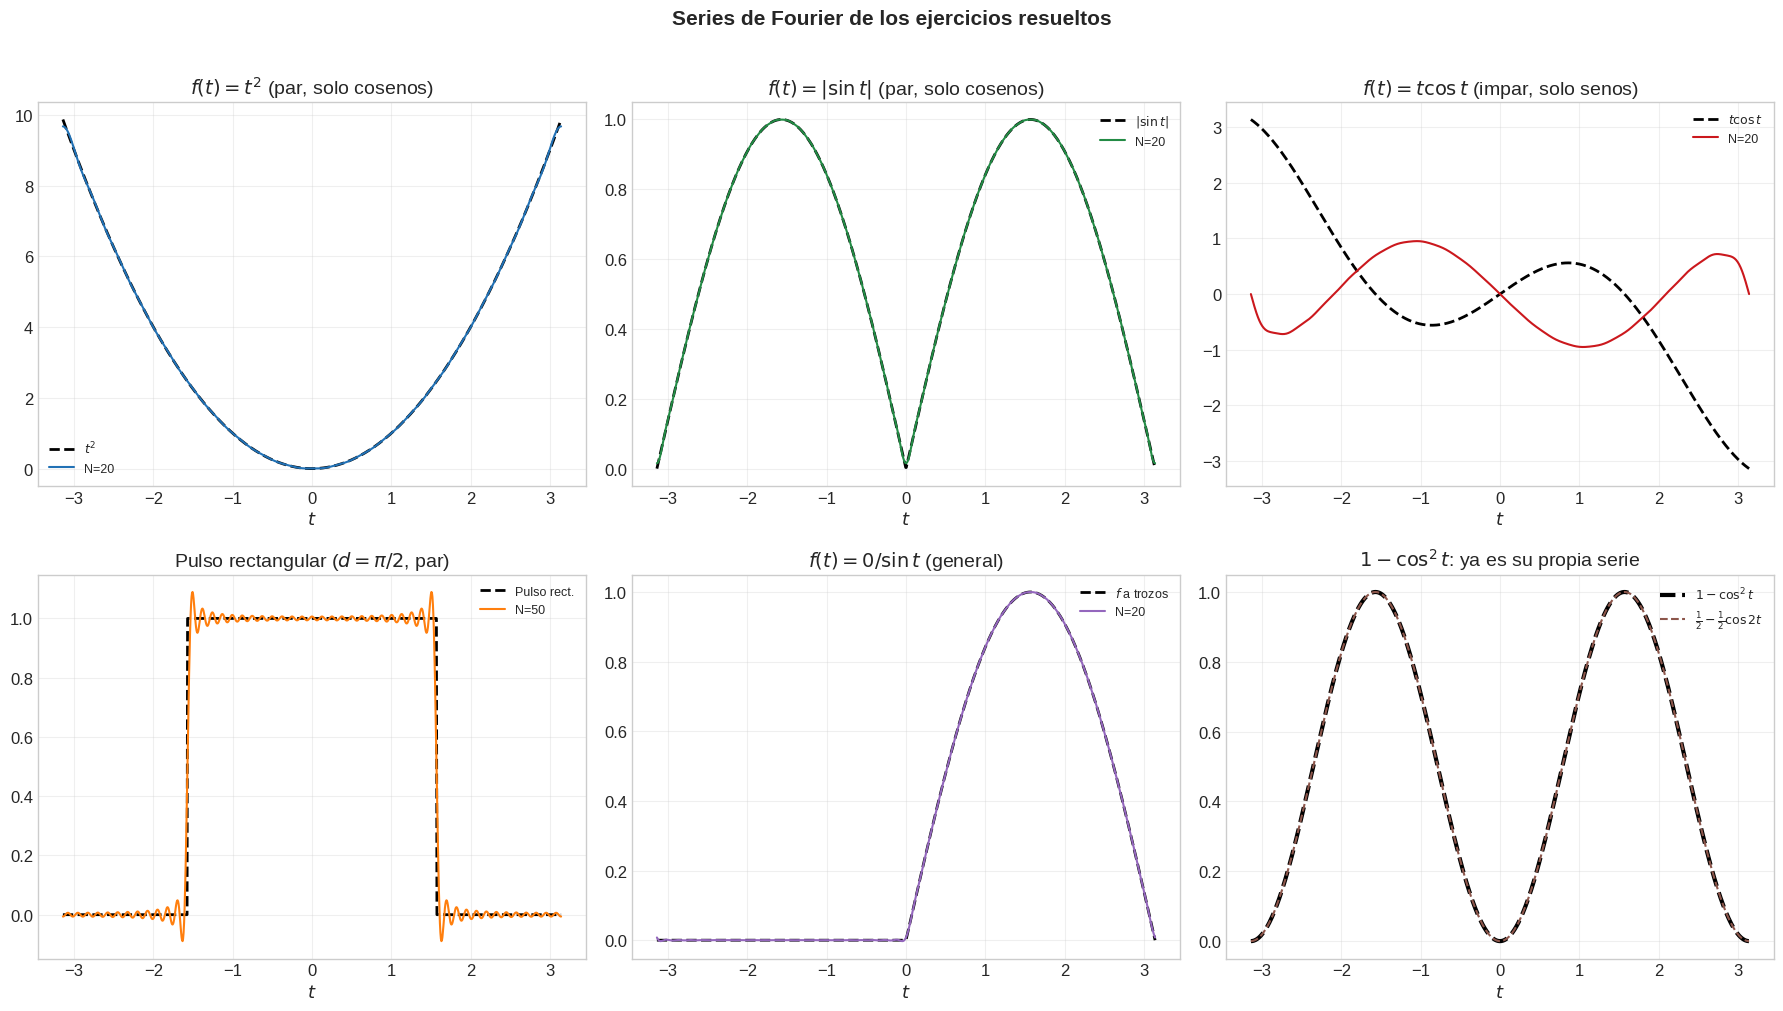

In [9]:
# Graficas de los ejercicios resueltos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

t = np.linspace(-np.pi, np.pi, 1000)
N_approx = 20

# 1. f(t) = t^2
ax = axes[0, 0]
f_exact = t**2
f_approx = np.pi**2 / 3 * np.ones_like(t)
for n in range(1, N_approx + 1):
    f_approx += (4 * (-1)**n / n**2) * np.cos(n * t)
ax.plot(t, f_exact, 'k--', lw=2, label=r'$t^2$')
ax.plot(t, f_approx, color=COLOR_PRINCIPAL, lw=1.5, label=f'N={N_approx}')
ax.set_title(r'$f(t) = t^2$ (par, solo cosenos)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2. f(t) = |sin(t)|
ax = axes[0, 1]
f_exact = np.abs(np.sin(t))
f_approx = 2 / np.pi * np.ones_like(t)
for k in range(1, N_approx + 1):
    f_approx -= (4 / np.pi) / (4 * k**2 - 1) * np.cos(2 * k * t)
ax.plot(t, f_exact, 'k--', lw=2, label=r'$|\sin t|$')
ax.plot(t, f_approx, color=COLOR_PUNTO, lw=1.5, label=f'N={N_approx}')
ax.set_title(r'$f(t) = |\sin t|$ (par, solo cosenos)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3. f(t) = t*cos(t)
ax = axes[0, 2]
f_exact = t * np.cos(t)
f_approx = -0.5 * np.sin(t)
for n in range(2, N_approx + 1):
    f_approx += 2 * (-1)**(n + 1) / (n**2 - 1) * np.sin(n * t)
ax.plot(t, f_exact, 'k--', lw=2, label=r'$t\cos t$')
ax.plot(t, f_approx, color=COLOR_RECTA, lw=1.5, label=f'N={N_approx}')
ax.set_title(r'$f(t) = t\cos t$ (impar, solo senos)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 4. Pulso rectangular (d = pi/2)
ax = axes[1, 0]
d = np.pi / 2
f_exact = np.where(np.abs(t) < d, 1.0, 0.0)
f_approx = d / np.pi * np.ones_like(t)
for n in range(1, 50 + 1):
    f_approx += (2 * np.sin(n * d) / (n * np.pi)) * np.cos(n * t)
ax.plot(t, f_exact, 'k--', lw=2, label='Pulso rect.')
ax.plot(t, f_approx, color=COLOR_AUX1, lw=1.5, label='N=50')
ax.set_title(r'Pulso rectangular ($d = \pi/2$, par)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 5. f(t) = 0/sin(t) a trozos
ax = axes[1, 1]
f_exact = np.where(t >= 0, np.sin(t), 0.0)
f_approx = 1 / np.pi * np.ones_like(t) + 0.5 * np.sin(t)
for k in range(1, N_approx + 1):
    f_approx -= (2 / np.pi) / (4 * k**2 - 1) * np.cos(2 * k * t)
ax.plot(t, f_exact, 'k--', lw=2, label=r'$f$ a trozos')
ax.plot(t, f_approx, color=COLOR_AUX2, lw=1.5, label=f'N={N_approx}')
ax.set_title(r'$f(t) = 0 / \sin t$ (general)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 6. f(t) = 1 - cos^2(t) = 1/2 - cos(2t)/2
ax = axes[1, 2]
f_exact = 1 - np.cos(t)**2
f_approx = 0.5 - 0.5 * np.cos(2 * t)
ax.plot(t, f_exact, 'k--', lw=3, label=r'$1 - \cos^2 t$')
ax.plot(t, f_approx, color=COLOR_AUX3, lw=1.5, ls='--',
        label=r'$\frac{1}{2} - \frac{1}{2}\cos 2t$')
ax.set_title(r'$1-\cos^2 t$: ya es su propia serie')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

for ax_row in axes:
    for ax in ax_row:
        ax.set_xlabel(r'$t$')

plt.suptitle('Series de Fourier de los ejercicios resueltos',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 10. Catálogo completo de ejercicios: todos los patrones

Esta sección clasifica los **12 tipos** de problemas de series de Fourier. Para cada tipo: fórmula clave, qué buscar primero, y un ejercicio resuelto.

### Tabla resumen

| # | Tipo | Qué buscar primero | Ecuación clave | Dificultad |
|---|------|-------------------|----------------|------------|
| 1 | Serie completa de $f$ par en $[-\pi,\pi]$ | $f(-t) = f(t)$ | $a_n = \frac{2}{\pi}\int_0^{\pi} f\cos(nt)\,dt$ | Media |
| 2 | Serie completa de $f$ impar en $[-\pi,\pi]$ | $f(-t) = -f(t)$ | $b_n = \frac{2}{\pi}\int_0^{\pi} f\sin(nt)\,dt$ | Media |
| 3 | Serie completa general (ambos $a_n, b_n$) | Ni par ni impar | Tres integrales | Alta |
| 4 | Serie de senos en $[0,\pi]$ | "Desarrolle en senos" | $b_n = \frac{2}{\pi}\int_0^{\pi} f\sin(nt)\,dt$ | Media |
| 5 | Serie de cosenos en $[0,\pi]$ | "Desarrolle en cosenos" | $a_n = \frac{2}{\pi}\int_0^{\pi} f\cos(nt)\,dt$ | Media |
| 6 | Serie compleja | Piden $c_n$ | $c_n = \frac{1}{2\pi}\int f e^{-jnt}\,dt$ | Media-Alta |
| 7 | Serie en intervalo general $[0,L]$ o $[-L,L]$ | $\omega = \pi/L$ | Sustituir $\omega$ en fórmulas | Media |
| 8 | Parseval para sumar series | "Deduzca la suma..." | $\frac{1}{T}\int|f|^2 = \sum|c_n|^2$ | Alta |
| 9 | Predecir coeficientes por simetría | Simetrías de $f$ | Tabla de patrones | Baja |
| 10 | Serie de función a trozos | Función con "si..." | Partir integral | Media-Alta |
| 11 | Función en $[0,2\pi]$ | Cambiar a $[-\pi,\pi]$ | Sustitución $u = t - \pi$ | Media |
| 12 | Convergencia en discontinuidad | "¿A qué converge en $t_0$?" | $\frac{f(t_0^+)+f(t_0^-)}{2}$ | Baja |

---

### 10.1 Tipo 1: Serie completa de función PAR en $[-\pi, \pi]$

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nt), \quad a_n = \frac{2}{\pi}\int_0^{\pi} f(t)\cos(nt)\,dt}$$

**Qué buscar PRIMERO:** verificar $f(-t) = f(t)$. Si es así, $b_n = 0$ automáticamente.

**Clave:** al ser par, la integral en $[-\pi, \pi]$ se reduce a $2\int_0^{\pi}$.

#### Ejercicio resuelto: $f(t) = \pi - |t|$ en $[-\pi, \pi]$

**Paso 0: Simetría.** $f(-t) = \pi - |-t| = \pi - |t| = f(t)$ $\to$ **par** $\to$ $b_n = 0$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{2}{\pi}\int_0^{\pi}(\pi - t)\,dt$$

(En $[0, \pi]$, $|t| = t$.)

$$a_0 = \frac{2}{\pi}\left[\pi t - \frac{t^2}{2}\right]_0^{\pi}$$

Evaluando en $t = \pi$: $\pi \cdot \pi - \frac{\pi^2}{2} = \pi^2 - \frac{\pi^2}{2} = \frac{\pi^2}{2}$

Evaluando en $t = 0$: $0$

$$a_0 = \frac{2}{\pi}\cdot\frac{\pi^2}{2} = \pi$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{2}{\pi}\int_0^{\pi}(\pi - t)\cos(nt)\,dt$$

Separamos en dos integrales:

$$a_n = \frac{2}{\pi}\left[\pi\int_0^{\pi}\cos(nt)\,dt - \int_0^{\pi} t\cos(nt)\,dt\right]$$

**Primera integral:**

$$\pi\int_0^{\pi}\cos(nt)\,dt = \pi\left[\frac{\sin(nt)}{n}\right]_0^{\pi} = \pi\cdot\frac{\sin(n\pi) - 0}{n} = 0$$

(porque $\sin(n\pi) = 0$ para todo entero $n$).

**Segunda integral (por partes).** Elegimos $u = t$, $dv = \cos(nt)\,dt$:

$$du = dt, \qquad v = \frac{\sin(nt)}{n}$$

$$\int_0^{\pi} t\cos(nt)\,dt = \left[\frac{t\sin(nt)}{n}\right]_0^{\pi} - \frac{1}{n}\int_0^{\pi}\sin(nt)\,dt$$

Primer termino: $\frac{\pi\sin(n\pi)}{n} - 0 = 0$

Segundo termino: $-\frac{1}{n}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi} = \frac{1}{n^2}[\cos(nt)]_0^{\pi} = \frac{\cos(n\pi) - 1}{n^2} = \frac{(-1)^n - 1}{n^2}$

Así: $\int_0^{\pi} t\cos(nt)\,dt = \frac{(-1)^n - 1}{n^2}$

**Sustituyendo:**

$$a_n = \frac{2}{\pi}\left[0 - \frac{(-1)^n - 1}{n^2}\right] = \frac{2(1 - (-1)^n)}{\pi n^2}$$

**Para $n$ par:** $(-1)^n = 1 \to 1 - 1 = 0 \to a_n = 0$.

**Para $n$ impar:** $(-1)^n = -1 \to 1 - (-1) = 2 \to a_n = \frac{4}{\pi n^2}$.

---

**Resultado final:**

Reindexando con $n = 2k+1$ (impares):

$$\boxed{\pi - |t| \sim \frac{\pi}{2} + \frac{4}{\pi}\sum_{k=0}^{\infty} \frac{\cos((2k+1)t)}{(2k+1)^2}}$$

Primeros terminos: $\pi - |t| \sim \frac{\pi}{2} + \frac{4}{\pi}\left(\cos t + \frac{\cos 3t}{9} + \frac{\cos 5t}{25} + \cdots\right)$

### 10.2 Tipo 2: Serie completa de función IMPAR en $[-\pi, \pi]$

$$\boxed{f(t) \sim \sum_{n=1}^{\infty} b_n \sin(nt), \quad b_n = \frac{2}{\pi}\int_0^{\pi} f(t)\sin(nt)\,dt}$$

**Qué buscar PRIMERO:** verificar $f(-t) = -f(t)$. Si es así, $a_n = 0$ y $a_0 = 0$.

#### Ejercicio resuelto: $f(t) = t$ en $[-\pi, \pi]$

**Paso 0: Simetría.** $f(-t) = -t = -f(t)$ $\to$ **impar** $\to$ $a_n = 0$ para todo $n$, $a_0 = 0$.

---

**Paso 1: Calcular $b_n$**

$$b_n = \frac{2}{\pi}\int_0^{\pi} t \sin(nt)\,dt$$

**Integración por partes.** Elegimos:

$$u = t, \qquad dv = \sin(nt)\,dt$$
$$du = dt, \qquad v = -\frac{\cos(nt)}{n}$$

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{\pi} t \sin(nt)\,dt = \left[-\frac{t\cos(nt)}{n}\right]_0^{\pi} + \frac{1}{n}\int_0^{\pi}\cos(nt)\,dt$$

**Evaluando el primer termino:**

$$-\frac{\pi\cos(n\pi)}{n} - \left(-\frac{0 \cdot \cos(0)}{n}\right) = -\frac{\pi\cos(n\pi)}{n} = -\frac{\pi(-1)^n}{n}$$

(Recordando que $\cos(n\pi) = (-1)^n$.)

**Evaluando el segundo termino:**

$$\frac{1}{n}\left[\frac{\sin(nt)}{n}\right]_0^{\pi} = \frac{1}{n^2}[\sin(n\pi) - \sin(0)] = \frac{0 - 0}{n^2} = 0$$

(Porque $\sin(n\pi) = 0$ para todo entero $n$.)

**Sustituyendo:**

$$\int_0^{\pi} t \sin(nt)\,dt = -\frac{\pi(-1)^n}{n} + 0 = -\frac{\pi(-1)^n}{n}$$

Por tanto:

$$b_n = \frac{2}{\pi}\cdot\left(-\frac{\pi(-1)^n}{n}\right) = \frac{-2(-1)^n}{n} = \frac{2(-1)^{n+1}}{n}$$

$$\boxed{b_n = \frac{2(-1)^{n+1}}{n}}$$

---

**Resultado final:**

$$\boxed{t \sim 2\sum_{n=1}^{\infty} \frac{(-1)^{n+1}}{n}\sin(nt) = 2\left(\sin t - \frac{\sin 2t}{2} + \frac{\sin 3t}{3} - \frac{\sin 4t}{4} + \cdots\right)}$$

---

**Convergencia en $t = \pi$:** En el extremo del intervalo, $f(\pi^-) = \pi$ y $f(-\pi^+) = -\pi$ (por periodicidad, el limite por la derecha en $\pi$ coincide con el limite por la izquierda en $-\pi$).

$$S(\pi) = \frac{f(\pi^-) + f(-\pi^+)}{2} = \frac{\pi + (-\pi)}{2} = 0 \neq \pi$$

La serie NO converge a $f(\pi)$ en el punto de discontinuidad de la extension periodica.

### 10.3 Tipo 3: Serie completa general (ni par ni impar)

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty}[a_n\cos(nt) + b_n\sin(nt)]}$$

**Qué buscar PRIMERO:** comprobar que $f$ no tiene simetría explotable. Si no la tiene, hay que calcular las tres integrales ($a_0$, $a_n$, $b_n$).

#### Ejercicio resuelto: $f(t) = e^t$ en $[-\pi, \pi]$

**Paso 0: Simetría.** $f(-t) = e^{-t} \neq \pm e^t$ $\to$ función general, no hay simplificacion.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi}\int_{-\pi}^{\pi} e^t\,dt = \frac{1}{\pi}\left[e^t\right]_{-\pi}^{\pi} = \frac{e^{\pi} - e^{-\pi}}{\pi} = \frac{2\sinh(\pi)}{\pi}$$

(Usando la definicion $\sinh(x) = \frac{e^x - e^{-x}}{2}$.)

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{1}{\pi}\int_{-\pi}^{\pi} e^t \cos(nt)\,dt$$

**Metodo: integración por partes doble (o formula directa).**

Calculamos $I = \int e^t\cos(nt)\,dt$. Integramos por partes dos veces:

*Primera vez:* $u = \cos(nt)$, $dv = e^t\,dt$ $\to$ $du = -n\sin(nt)\,dt$, $v = e^t$:

$$I = e^t\cos(nt) + n\int e^t\sin(nt)\,dt$$

*Segunda vez:* para $J = \int e^t\sin(nt)\,dt$, tomamos $u = \sin(nt)$, $dv = e^t\,dt$:

$$J = e^t\sin(nt) - n\int e^t\cos(nt)\,dt = e^t\sin(nt) - nI$$

Sustituyendo en la primera:

$$I = e^t\cos(nt) + n[e^t\sin(nt) - nI] = e^t\cos(nt) + ne^t\sin(nt) - n^2 I$$

$$I + n^2 I = e^t[\cos(nt) + n\sin(nt)]$$

$$\boxed{I = \int e^t\cos(nt)\,dt = \frac{e^t(\cos(nt) + n\sin(nt))}{1 + n^2}}$$

Evaluando en los limites $[-\pi, \pi]$:

$$\int_{-\pi}^{\pi} e^t\cos(nt)\,dt = \frac{1}{1+n^2}\left[e^t(\cos(nt) + n\sin(nt))\right]_{-\pi}^{\pi}$$

En $t = \pi$: $e^{\pi}(\cos(n\pi) + n\sin(n\pi)) = e^{\pi}\cdot(-1)^n$ (pues $\sin(n\pi) = 0$)

En $t = -\pi$: $e^{-\pi}(\cos(-n\pi) + n\sin(-n\pi)) = e^{-\pi}\cdot(-1)^n$ (pues $\cos(-n\pi) = (-1)^n$, $\sin(-n\pi) = 0$)

$$= \frac{(-1)^n(e^{\pi} - e^{-\pi})}{1+n^2} = \frac{2(-1)^n\sinh(\pi)}{1+n^2}$$

Por tanto:

$$\boxed{a_n = \frac{2(-1)^n\sinh(\pi)}{\pi(1+n^2)}}$$

---

**Paso 3: Calcular $b_n$**

$$b_n = \frac{1}{\pi}\int_{-\pi}^{\pi} e^t \sin(nt)\,dt$$

Analogamente, usando $J = \frac{e^t(\sin(nt) - n\cos(nt))}{1+n^2}$:

En $t = \pi$: $e^{\pi}(\sin(n\pi) - n\cos(n\pi)) = e^{\pi}\cdot(-n)(-1)^n$

En $t = -\pi$: $e^{-\pi}(\sin(-n\pi) - n\cos(-n\pi)) = e^{-\pi}\cdot(-n)(-1)^n$

$$\int_{-\pi}^{\pi} e^t\sin(nt)\,dt = \frac{-n(-1)^n(e^{\pi} - e^{-\pi})}{1+n^2} = \frac{-2n(-1)^n\sinh(\pi)}{1+n^2}$$

$$\boxed{b_n = \frac{-2n(-1)^n\sinh(\pi)}{\pi(1+n^2)}}$$

---

**Resultado final:**

Factorizando el termino comun $\frac{2\sinh\pi}{\pi}\cdot\frac{(-1)^n}{1+n^2}$:

$$a_n\cos(nt) + b_n\sin(nt) = \frac{2(-1)^n\sinh\pi}{\pi(1+n^2)}[\cos(nt) - n\sin(nt)]$$

$$\boxed{e^t \sim \frac{\sinh\pi}{\pi} + \frac{2\sinh\pi}{\pi}\sum_{n=1}^{\infty}\frac{(-1)^n}{1+n^2}[\cos(nt) - n\sin(nt)]}$$

### 10.4 Tipo 4: Serie de senos en $[0, \pi]$ (extensión impar)

$$\boxed{f(t) \sim \sum_{n=1}^{\infty} b_n \sin(nt), \quad b_n = \frac{2}{\pi}\int_0^{\pi} f(t)\sin(nt)\,dt}$$

**Qué buscar PRIMERO:** el enunciado dice "serie de senos" o "extensión impar". La función solo está definida en $[0, \pi]$ (o $[0, L]$).

**Clave:** la serie converge a $0$ en $t = 0$ y $t = \pi$ (la extensión impar es $0$ en los extremos).

#### Ejercicio resuelto: Serie de senos de $f(t) = 1$ en $[0, \pi]$

**Paso 1: Plantear la integral**

$$b_n = \frac{2}{\pi}\int_0^{\pi} 1 \cdot \sin(nt)\,dt = \frac{2}{\pi}\int_0^{\pi} \sin(nt)\,dt$$

**Paso 2: Integrar**

$$b_n = \frac{2}{\pi}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi}$$

**Paso 3: Evaluar en los limites**

En $t = \pi$: $-\frac{\cos(n\pi)}{n} = -\frac{(-1)^n}{n}$

En $t = 0$: $-\frac{\cos(0)}{n} = -\frac{1}{n}$

Restando:

$$b_n = \frac{2}{\pi}\left[-\frac{(-1)^n}{n} - \left(-\frac{1}{n}\right)\right] = \frac{2}{\pi}\cdot\frac{1 - (-1)^n}{n}$$

**Paso 4: Analizar segun la paridad de $n$**

**Para $n$ par:** $(-1)^n = 1 \to 1 - 1 = 0 \to b_n = 0$.

**Para $n$ impar:** $(-1)^n = -1 \to 1 - (-1) = 2 \to b_n = \frac{4}{n\pi}$.

---

**Resultado final:**

Reindexando con $n = 2k+1$:

$$\boxed{1 \sim \frac{4}{\pi}\sum_{k=0}^{\infty} \frac{\sin((2k+1)t)}{2k+1} = \frac{4}{\pi}\left(\sin t + \frac{\sin 3t}{3} + \frac{\sin 5t}{5} + \cdots\right), \qquad t \in (0, \pi)}$$

---

**Nota sobre convergencia:** En $t = 0$ la serie vale $0$ (todos los senos son $0$), no $1$. Esto es coherente: la extensión impar tiene un salto de $-1$ a $+1$ en $t = 0$, y el promedio $\frac{-1+1}{2} = 0$. Igualmente en $t = \pi$: la serie da $0$, no $1$.

### 10.5 Tipo 5: Serie de cosenos en $[0, \pi]$ (extensión par)

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nt), \quad a_n = \frac{2}{\pi}\int_0^{\pi} f(t)\cos(nt)\,dt}$$

**Qué buscar PRIMERO:** el enunciado dice "serie de cosenos" o "extensión par".

**Clave:** la serie converge a $f(0)$ y $f(\pi)$ en los extremos (la extensión par es continua ahí si $f$ lo es).

#### Ejercicio resuelto: Serie de cosenos de $f(t) = t$ en $[0, \pi]$

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{2}{\pi}\int_0^{\pi} t\,dt = \frac{2}{\pi} \left[\frac{t^2}{2}\right]_0^{\pi} = \frac{2}{\pi} \cdot \frac{\pi^2}{2} = \pi$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{2}{\pi}\int_0^{\pi} t\cos(nt)\,dt$$

**Integración por partes.** Elegimos:

$$u = t, \qquad dv = \cos(nt)\,dt$$
$$du = dt, \qquad v = \frac{\sin(nt)}{n}$$

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{\pi} t\cos(nt)\,dt = \left[\frac{t\sin(nt)}{n}\right]_0^{\pi} - \frac{1}{n}\int_0^{\pi}\sin(nt)\,dt$$

**Evaluando el primer termino:**

$$\frac{\pi\sin(n\pi)}{n} - \frac{0\cdot\sin(0)}{n} = 0 - 0 = 0$$

(Porque $\sin(n\pi) = 0$ para todo entero $n$.)

**Evaluando el segundo termino:**

$$-\frac{1}{n}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi} = \frac{1}{n^2}\left[\cos(nt)\right]_0^{\pi} = \frac{1}{n^2}[\cos(n\pi) - \cos(0)] = \frac{(-1)^n - 1}{n^2}$$

**Resultado:**

$$a_n = \frac{2}{\pi}\cdot\frac{(-1)^n - 1}{n^2} = \frac{2((-1)^n - 1)}{\pi n^2}$$

**Para $n$ par:** $(-1)^n = 1 \to a_n = 0$.

**Para $n$ impar:** $(-1)^n = -1 \to a_n = \frac{2(-2)}{\pi n^2} = \frac{-4}{\pi n^2}$.

---

**Resultado final:**

Reindexando con $n = 2k+1$:

$$\boxed{t \sim \frac{\pi}{2} - \frac{4}{\pi}\sum_{k=0}^{\infty} \frac{\cos((2k+1)t)}{(2k+1)^2}, \qquad t \in [0, \pi]}$$

$$= \frac{\pi}{2} - \frac{4}{\pi}\left(\cos t + \frac{\cos 3t}{9} + \frac{\cos 5t}{25} + \cdots\right)$$

**Verificacion en $t = 0$:** $S(0) = \frac{\pi}{2} - \frac{4}{\pi}\sum_{k=0}^{\infty}\frac{1}{(2k+1)^2}$. Como $f(0) = 0$, se deduce $\sum_{k=0}^{\infty}\frac{1}{(2k+1)^2} = \frac{\pi^2}{8}$.

### 10.6 Tipo 6: Serie de Fourier compleja

$$\boxed{c_n = \frac{1}{2\pi}\int_{-\pi}^{\pi} f(t)\,e^{-jnt}\,dt, \qquad f(t) \sim \sum_{n=-\infty}^{\infty} c_n\,e^{jnt}}$$

**Qué buscar PRIMERO:** si $f$ es real, verificar simetría conjugada $c_{-n} = \overline{c_n}$ para reducir trabajo a la mitad.

#### Ejercicio resuelto: $c_n$ de $f(t) = e^{at}$ en $[-\pi, \pi]$, $a \neq jn$

**Paso 1: Plantear la integral**

$$c_n = \frac{1}{2\pi}\int_{-\pi}^{\pi} e^{at}e^{-jnt}\,dt = \frac{1}{2\pi}\int_{-\pi}^{\pi} e^{(a-jn)t}\,dt$$

**Paso 2: Integrar la exponencial**

La primitiva de $e^{(a-jn)t}$ es $\frac{e^{(a-jn)t}}{a-jn}$ (valido porque $a - jn \neq 0$):

$$c_n = \frac{1}{2\pi}\cdot\frac{e^{(a-jn)t}}{a-jn}\Bigg|_{-\pi}^{\pi}$$

**Paso 3: Evaluar en los limites**

$$c_n = \frac{1}{2\pi(a-jn)}\left[e^{(a-jn)\pi} - e^{-(a-jn)\pi}\right]$$

**Paso 4: Reconocer el seno hiperbolico**

Recordando que $\sinh(z) = \frac{e^z - e^{-z}}{2}$:

$$e^{(a-jn)\pi} - e^{-(a-jn)\pi} = 2\sinh((a-jn)\pi)$$

$$c_n = \frac{2\sinh((a-jn)\pi)}{2\pi(a-jn)} = \frac{\sinh((a-jn)\pi)}{\pi(a-jn)}$$

**Paso 5: Simplificar para $a$ real**

Expandimos $\sinh((a-jn)\pi)$ usando $\sinh(x + iy) = \sinh(x)\cos(y) + j\cosh(x)\sin(y)$:

$$\sinh((a-jn)\pi) = \sinh(a\pi - jn\pi) = \sinh(a\pi)\cos(n\pi) + j\cosh(a\pi)\sin(-n\pi)$$

Como $\cos(n\pi) = (-1)^n$ y $\sin(n\pi) = 0$:

$$\sinh((a-jn)\pi) = (-1)^n\sinh(a\pi)$$

Por tanto:

$$\boxed{c_n = \frac{(-1)^n \sinh(a\pi)}{\pi(a - jn)}}$$

---

**Verificacion de consistencia con la serie real (Tipo 3):**

Para $a = 1$ (caso $e^t$), tenemos $c_n = \frac{(-1)^n\sinh\pi}{\pi(1-jn)}$. Multiplicando por el conjugado:

$$c_n = \frac{(-1)^n\sinh\pi}{\pi}\cdot\frac{1+jn}{1+n^2}$$

Las relaciones $a_n = c_n + c_{-n}$ y $b_n = j(c_n - c_{-n})$ dan exactamente los coeficientes del Tipo 3.

### 10.7 Tipo 7: Serie en intervalo general $[-L, L]$ o $[0, L]$

$$\boxed{f(t) \sim \frac{a_0}{2} + \sum_{n=1}^{\infty}\left[a_n\cos\left(\frac{n\pi t}{L}\right) + b_n\sin\left(\frac{n\pi t}{L}\right)\right]}$$

$$a_n = \frac{1}{L}\int_{-L}^{L} f(t)\cos\left(\frac{n\pi t}{L}\right)dt, \qquad b_n = \frac{1}{L}\int_{-L}^{L} f(t)\sin\left(\frac{n\pi t}{L}\right)dt$$

**Qué buscar PRIMERO:** identificar $L$ (semilongitud del intervalo). La frecuencia fundamental es $\omega = \pi/L$, **no** $2\pi/T$.

#### Ejercicio resuelto: $f(t) = t$ en $[-2, 2]$ ($L = 2$)

**Paso 0: Simetría.** $f(-t) = -t = -f(t)$ $\to$ impar $\to$ $a_n = 0$ para todo $n$, $a_0 = 0$.

---

**Paso 1: Calcular $b_n$**

Con $L = 2$ y la formula para funcion impar:

$$b_n = \frac{2}{L}\int_0^{L} f(t)\sin\left(\frac{n\pi t}{L}\right)dt = \frac{2}{2}\int_0^{2} t\sin\left(\frac{n\pi t}{2}\right)dt = \int_0^{2} t\sin\left(\frac{n\pi t}{2}\right)dt$$

**Integración por partes.** Elegimos:

$$u = t, \qquad dv = \sin\left(\frac{n\pi t}{2}\right)dt$$
$$du = dt, \qquad v = -\frac{2\cos(n\pi t/2)}{n\pi}$$

(La primitiva de $\sin(\alpha t)$ es $-\frac{\cos(\alpha t)}{\alpha}$ con $\alpha = n\pi/2$.)

Aplicando $\int u\,dv = uv - \int v\,du$:

$$\int_0^{2} t\sin\left(\frac{n\pi t}{2}\right)dt = \left[-\frac{2t\cos(n\pi t/2)}{n\pi}\right]_0^{2} + \frac{2}{n\pi}\int_0^{2}\cos\left(\frac{n\pi t}{2}\right)dt$$

**Evaluando el primer termino:**

En $t = 2$: $-\frac{2\cdot 2 \cdot\cos(n\pi \cdot 2/2)}{n\pi} = -\frac{4\cos(n\pi)}{n\pi} = -\frac{4(-1)^n}{n\pi}$

En $t = 0$: $-\frac{0}{n\pi} = 0$

Primer termino: $-\frac{4(-1)^n}{n\pi}$

**Evaluando el segundo termino:**

$$\frac{2}{n\pi}\left[\frac{2\sin(n\pi t/2)}{n\pi}\right]_0^{2} = \frac{4}{n^2\pi^2}\left[\sin(n\pi) - \sin(0)\right] = \frac{4}{n^2\pi^2}\cdot 0 = 0$$

(Porque $\sin(n\pi) = 0$ para todo entero $n$.)

**Resultado:**

$$b_n = -\frac{4(-1)^n}{n\pi} = \frac{4(-1)^{n+1}}{n\pi}$$

$$\boxed{b_n = \frac{4(-1)^{n+1}}{n\pi}}$$

---

**Resultado final:**

$$\boxed{t \sim \frac{4}{\pi}\sum_{n=1}^{\infty}\frac{(-1)^{n+1}}{n}\sin\left(\frac{n\pi t}{2}\right), \qquad t \in (-2, 2)}$$

$$= \frac{4}{\pi}\left(\sin\frac{\pi t}{2} - \frac{1}{2}\sin(\pi t) + \frac{1}{3}\sin\frac{3\pi t}{2} - \cdots\right)$$

Notar la similitud con la serie de $f(t) = t$ en $[-\pi, \pi]$: la estructura es identica, solo cambia la frecuencia fundamental de $1$ a $\pi/2$.

### 10.8 Tipo 8: Parseval para sumar series numéricas

$$\boxed{\frac{1}{T}\int_{-T/2}^{T/2} |f(t)|^2\,dt = \frac{a_0^2}{4} + \frac{1}{2}\sum_{n=1}^{\infty}(a_n^2 + b_n^2)}$$

**Qué buscar PRIMERO:** identificar qué serie nos piden sumar, luego encontrar una función $f$ cuya serie de Fourier la contenga.

**Estrategia inversa:** si ya tenemos la serie de Fourier de alguna $f$, Parseval nos da "gratis" la suma de los cuadrados de los coeficientes.

#### Ejercicio resuelto: Calcular $\sum_{n=1}^{\infty} \frac{1}{n^4}$

**Paso 0: Elegir la funcion adecuada.**

Necesitamos coeficientes con $1/n^2$ para que sus cuadrados den $1/n^4$. La serie de $f(t) = t^2$ tiene $a_n = \frac{4(-1)^n}{n^2}$, asi que $a_n^2 = \frac{16}{n^4}$. Perfecto.

Datos de $f(t) = t^2$ en $[-\pi, \pi]$ (del Ejercicio 9.1):
- $a_0 = \frac{2\pi^2}{3}$
- $a_n = \frac{4(-1)^n}{n^2}$
- $b_n = 0$ (funcion par)

---

**Paso 1: Calcular el lado izquierdo de Parseval**

$$\frac{1}{2\pi}\int_{-\pi}^{\pi} (t^2)^2\,dt = \frac{1}{2\pi}\int_{-\pi}^{\pi} t^4\,dt$$

Como $t^4$ es par:

$$= \frac{1}{2\pi}\cdot 2\int_0^{\pi} t^4\,dt = \frac{1}{\pi}\left[\frac{t^5}{5}\right]_0^{\pi} = \frac{1}{\pi}\cdot\frac{\pi^5}{5} = \frac{\pi^4}{5}$$

---

**Paso 2: Calcular el lado derecho de Parseval**

$$\frac{a_0^2}{4} + \frac{1}{2}\sum_{n=1}^{\infty} a_n^2$$

Termino $a_0$:

$$\frac{a_0^2}{4} = \frac{1}{4}\left(\frac{2\pi^2}{3}\right)^2 = \frac{1}{4}\cdot\frac{4\pi^4}{9} = \frac{\pi^4}{9}$$

Terminos $a_n$:

$$\frac{1}{2}\sum_{n=1}^{\infty} a_n^2 = \frac{1}{2}\sum_{n=1}^{\infty}\left(\frac{4(-1)^n}{n^2}\right)^2 = \frac{1}{2}\sum_{n=1}^{\infty}\frac{16}{n^4} = 8\sum_{n=1}^{\infty}\frac{1}{n^4}$$

---

**Paso 3: Igualar ambos lados**

$$\frac{\pi^4}{5} = \frac{\pi^4}{9} + 8\sum_{n=1}^{\infty}\frac{1}{n^4}$$

Despejando:

$$8\sum_{n=1}^{\infty}\frac{1}{n^4} = \frac{\pi^4}{5} - \frac{\pi^4}{9} = \pi^4\left(\frac{9 - 5}{45}\right) = \frac{4\pi^4}{45}$$

$$\sum_{n=1}^{\infty}\frac{1}{n^4} = \frac{4\pi^4}{45 \cdot 8} = \frac{4\pi^4}{360} = \frac{\pi^4}{90}$$

$$\boxed{\sum_{n=1}^{\infty} \frac{1}{n^4} = \frac{\pi^4}{90}}$$

Este resultado es $\zeta(4) = \frac{\pi^4}{90}$, donde $\zeta$ es la funcion zeta de Riemann.

### 10.9 Tipo 9: Predecir coeficientes por simetría

No requiere calcular integrales. Solo análisis de propiedades.

**Qué buscar PRIMERO:** todas las simetrías posibles (par, impar, media onda, combinaciones).

**Tabla de reglas de simetría:**

| Propiedad de $f$ | Consecuencia |
|---|---|
| $f(-t) = f(t)$ (par) | $b_n = 0$, solo cosenos |
| $f(-t) = -f(t)$ (impar) | $a_n = 0$, solo senos |
| $f(t + T/2) = -f(t)$ (media onda) | Solo armonicos impares ($n$ impar) |
| $f$ real | $c_{-n} = \overline{c_n}$ |
| $f$ real y par | $c_n$ real |
| $f$ real e impar | $c_n$ puramente imaginario |

---

#### Ejercicio resuelto: Predecir la forma de la serie de $f(t) = t^3$ en $[-\pi, \pi]$

**Analisis paso a paso:**

**1. Paridad:** $f(-t) = (-t)^3 = -t^3 = -f(t)$ $\to$ **impar** $\to$ $a_0 = a_n = 0$, solo senos.

**2. Simetría de media onda:** $f(t + \pi) = (t + \pi)^3$. Para que haya simetría de media onda, necesitariamos $(t+\pi)^3 = -t^3$, lo cual NO se cumple (basta probar $t=0$: $\pi^3 \neq 0$). $\to$ **no** tiene simetría de media onda $\to$ aparecen todos los $n$ (pares e impares).

**3. Regularidad:** $f$ es un polinomio, infinitamente diferenciable. La teoria dice que si $f$ es $k$ veces diferenciable, $|c_n| \sim 1/n^{k+1}$. Como $t^3$ es $C^{\infty}$ en el interior, pero la extension periodica tiene salto en $\pm\pi$ (pues $f(\pi) = \pi^3 \neq f(-\pi) = -\pi^3$ como limites laterales). Entonces el decaimiento es $|b_n| \sim 1/n^{\text{algo}}$. Al tener la primera derivada continua pero discontinuidad de la funcion en la extension, $|b_n| \sim 1/n$ (como en $f(t)=t$), pero de hecho $t^3$ tiene un decaimiento mas rapido tipo $\sim 1/n$.

**4. Coeficientes complejos:** $f$ real e impar $\to$ $c_n$ puramente imaginario.

**Predicción sin calcular nada:**

$$t^3 \sim \sum_{n=1}^{\infty} b_n \sin(nt), \quad \text{con todos los } n \text{ (pares e impares)}$$

---

#### Ejercicio resuelto: $f(t) = |t|$ en $[-\pi, \pi]$

**Analisis paso a paso:**

**1. Paridad:** $f(-t) = |-t| = |t| = f(t)$ $\to$ **par** $\to$ solo cosenos, $b_n = 0$.

**2. Simetría de media onda:** $f(t + \pi) = |t + \pi|$. Para $t = 0$: $|\pi| = \pi \neq -|0| = 0$. $\to$ **no** hay simetría de media onda $\to$ todos los $n$.

**3. Regularidad:** $f$ es continua pero con "pico" en $t = 0$ (derivada no existe). La extension periodica es continua pero no derivable en $t = 0, \pm\pi, \pm 2\pi, \ldots$. Para funciones continuas con derivada a trozos: $|c_n| \sim 1/n^2$.

**Predicción:**

$$|t| \sim \frac{a_0}{2} + \sum_{n=1}^{\infty} a_n \cos(nt), \quad \text{con todos los } n, \quad |a_n| \sim \frac{C}{n^2}$$

### 10.10 Tipo 10: Serie de función a trozos

**Qué buscar PRIMERO:** los puntos donde cambia la definición. La integral se parte en subintervalos.

**Estrategia general:**
1. Identificar los trozos y sus intervalos
2. Comprobar simetría (a veces la funcion a trozos es par o impar)
3. Partir cada integral $\int_{-\pi}^{\pi}$ en la suma de las integrales sobre cada trozo

#### Ejercicio resuelto: $f(t) = \begin{cases} -1 & -\pi < t < 0 \\ t & 0 \leq t < \pi \end{cases}$

**Paso 0: Simetría.** $f(-\pi/2) = -1$ y $f(\pi/2) = \pi/2$. Comprobamos: $f(-\pi/2) = -1 \neq f(\pi/2) = \pi/2$, asi que $f$ no es par. Tambien $f(-\pi/2) = -1 \neq -f(\pi/2) = -\pi/2$, asi que no es impar. $\to$ **función general**, calcular $a_0$, $a_n$ y $b_n$.

---

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi}\int_{-\pi}^{\pi} f(t)\,dt = \frac{1}{\pi}\left[\int_{-\pi}^{0}(-1)\,dt + \int_0^{\pi} t\,dt\right]$$

Primera integral: $\int_{-\pi}^{0}(-1)\,dt = [-t]_{-\pi}^{0} = 0 - \pi = -\pi$

Segunda integral: $\int_0^{\pi} t\,dt = \left[\frac{t^2}{2}\right]_0^{\pi} = \frac{\pi^2}{2}$

$$a_0 = \frac{1}{\pi}\left[-\pi + \frac{\pi^2}{2}\right] = -1 + \frac{\pi}{2} = \frac{\pi - 2}{2}$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{1}{\pi}\left[\int_{-\pi}^{0}(-1)\cos(nt)\,dt + \int_0^{\pi} t\cos(nt)\,dt\right]$$

**Primera integral:**

$$\int_{-\pi}^{0}(-1)\cos(nt)\,dt = -\left[\frac{\sin(nt)}{n}\right]_{-\pi}^{0} = -\left[\frac{\sin(0)}{n} - \frac{\sin(-n\pi)}{n}\right] = -[0 - 0] = 0$$

(Porque $\sin(0) = 0$ y $\sin(-n\pi) = 0$.)

**Segunda integral (por partes).** Elegimos $u = t$, $dv = \cos(nt)\,dt$:

$$du = dt, \qquad v = \frac{\sin(nt)}{n}$$

$$\int_0^{\pi} t\cos(nt)\,dt = \left[\frac{t\sin(nt)}{n}\right]_0^{\pi} - \frac{1}{n}\int_0^{\pi}\sin(nt)\,dt$$

Primer termino: $\frac{\pi\sin(n\pi)}{n} - 0 = 0$

Segundo termino: $-\frac{1}{n}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi} = \frac{1}{n^2}[\cos(n\pi) - 1] = \frac{(-1)^n - 1}{n^2}$

Así: $\int_0^{\pi} t\cos(nt)\,dt = \frac{(-1)^n - 1}{n^2}$

**Resultado:**

$$a_n = \frac{1}{\pi}\left[0 + \frac{(-1)^n - 1}{n^2}\right] = \frac{(-1)^n - 1}{\pi n^2}$$

**Para $n$ par:** $(-1)^n = 1 \to a_n = 0$.

**Para $n$ impar:** $(-1)^n = -1 \to a_n = \frac{-2}{\pi n^2}$.

---

**Paso 3: Calcular $b_n$**

$$b_n = \frac{1}{\pi}\left[\int_{-\pi}^{0}(-1)\sin(nt)\,dt + \int_0^{\pi} t\sin(nt)\,dt\right]$$

**Primera integral:**

$$\int_{-\pi}^{0}(-1)\sin(nt)\,dt = -\left[-\frac{\cos(nt)}{n}\right]_{-\pi}^{0} = \frac{1}{n}[\cos(nt)]_{-\pi}^{0} = \frac{1}{n}[\cos(0) - \cos(-n\pi)]$$

$$= \frac{1}{n}[1 - (-1)^n] = \frac{1 - (-1)^n}{n}$$

**Segunda integral (por partes).** Elegimos $u = t$, $dv = \sin(nt)\,dt$:

$$du = dt, \qquad v = -\frac{\cos(nt)}{n}$$

$$\int_0^{\pi} t\sin(nt)\,dt = \left[-\frac{t\cos(nt)}{n}\right]_0^{\pi} + \frac{1}{n}\int_0^{\pi}\cos(nt)\,dt$$

Primer termino: $-\frac{\pi\cos(n\pi)}{n} - 0 = -\frac{\pi(-1)^n}{n}$

Segundo termino: $\frac{1}{n}\left[\frac{\sin(nt)}{n}\right]_0^{\pi} = 0$

Así: $\int_0^{\pi} t\sin(nt)\,dt = -\frac{\pi(-1)^n}{n}$

**Resultado:**

$$b_n = \frac{1}{\pi}\left[\frac{1 - (-1)^n}{n} + \left(-\frac{\pi(-1)^n}{n}\right)\right] = \frac{1 - (-1)^n}{\pi n} - \frac{(-1)^n}{n}$$

$$\boxed{b_n = \frac{1 - (-1)^n}{\pi n} - \frac{(-1)^n}{n}}$$

Simplificando para valores concretos:

**Para $n$ par** ($(-1)^n = 1$): $b_n = 0 - \frac{1}{n} = -\frac{1}{n}$

**Para $n$ impar** ($(-1)^n = -1$): $b_n = \frac{2}{\pi n} + \frac{1}{n} = \frac{1}{n}\left(\frac{2}{\pi} + 1\right) = \frac{\pi + 2}{\pi n}$

---

**Convergencia en $t = 0$ (punto de discontinuidad):**

$$S(0) = \frac{f(0^+) + f(0^-)}{2} = \frac{0 + (-1)}{2} = -\frac{1}{2}$$

La serie converge al promedio de los limites laterales, no a $f(0) = 0$.

### 10.11 Tipo 11: Función definida en $[0, 2\pi]$

**Qué buscar PRIMERO:** el intervalo es $[0, 2\pi]$ en vez de $[-\pi, \pi]$. Se puede:
- (a) Integrar directamente en $[0, 2\pi]$ (las fórmulas son válidas en cualquier intervalo de longitud $T$)
- (b) Hacer el cambio $u = t - \pi$ para trasladar a $[-\pi, \pi]$

**Clave:** la serie de Fourier NO cambia, solo cambian los límites de integración.

#### Ejercicio resuelto: $f(t) = t$ en $[0, 2\pi]$

**Paso 1: Calcular $a_0$**

$$a_0 = \frac{1}{\pi}\int_0^{2\pi} t\,dt = \frac{1}{\pi}\left[\frac{t^2}{2}\right]_0^{2\pi} = \frac{1}{\pi}\cdot\frac{4\pi^2}{2} = \frac{1}{\pi}\cdot 2\pi^2 = 2\pi$$

---

**Paso 2: Calcular $a_n$ ($n \geq 1$)**

$$a_n = \frac{1}{\pi}\int_0^{2\pi} t\cos(nt)\,dt$$

**Integración por partes.** Elegimos $u = t$, $dv = \cos(nt)\,dt$:

$$du = dt, \qquad v = \frac{\sin(nt)}{n}$$

$$\int_0^{2\pi} t\cos(nt)\,dt = \left[\frac{t\sin(nt)}{n}\right]_0^{2\pi} - \frac{1}{n}\int_0^{2\pi}\sin(nt)\,dt$$

**Primer termino:** $\frac{2\pi\sin(2n\pi)}{n} - 0 = 0$ (porque $\sin(2n\pi) = 0$ para todo entero $n$).

**Segundo termino:**

$$-\frac{1}{n}\left[-\frac{\cos(nt)}{n}\right]_0^{2\pi} = \frac{1}{n^2}[\cos(2n\pi) - \cos(0)] = \frac{1}{n^2}[1 - 1] = 0$$

(Porque $\cos(2n\pi) = 1$ para todo entero $n$.)

$$a_n = \frac{1}{\pi}\cdot 0 = 0$$

**Todos los $a_n$ son cero** (para $n \geq 1$). Esto tiene sentido: al no haber simetria par en $[0, 2\pi]$, los cosenos no contribuyen.

---

**Paso 3: Calcular $b_n$**

$$b_n = \frac{1}{\pi}\int_0^{2\pi} t\sin(nt)\,dt$$

**Integración por partes.** Elegimos $u = t$, $dv = \sin(nt)\,dt$:

$$du = dt, \qquad v = -\frac{\cos(nt)}{n}$$

$$\int_0^{2\pi} t\sin(nt)\,dt = \left[-\frac{t\cos(nt)}{n}\right]_0^{2\pi} + \frac{1}{n}\int_0^{2\pi}\cos(nt)\,dt$$

**Primer termino:**

$$-\frac{2\pi\cos(2n\pi)}{n} - \left(-\frac{0}{n}\right) = -\frac{2\pi \cdot 1}{n} = -\frac{2\pi}{n}$$

(Porque $\cos(2n\pi) = 1$.)

**Segundo termino:**

$$\frac{1}{n}\left[\frac{\sin(nt)}{n}\right]_0^{2\pi} = \frac{1}{n^2}[\sin(2n\pi) - \sin(0)] = 0$$

Así: $\int_0^{2\pi} t\sin(nt)\,dt = -\frac{2\pi}{n}$

$$b_n = \frac{1}{\pi}\cdot\left(-\frac{2\pi}{n}\right) = \frac{-2}{n}$$

$$\boxed{b_n = \frac{-2}{n}}$$

---

**Resultado final:**

$$\boxed{t \sim \pi - 2\sum_{n=1}^{\infty}\frac{\sin(nt)}{n}, \qquad t \in (0, 2\pi)}$$

$$= \pi - 2\left(\sin t + \frac{\sin 2t}{2} + \frac{\sin 3t}{3} + \cdots\right)$$

---

**Nota sobre convergencia en los extremos:** En $t = 0$ (y $t = 2\pi$, que es el mismo punto por periodicidad):

$$S(0) = \frac{f(0^+) + f(2\pi^-)}{2} = \frac{0 + 2\pi}{2} = \pi$$

La serie converge a $\pi$, no a $f(0) = 0$. Coherente: el termino constante es $\pi$ y todos los senos valen $0$ en $t = 0$.

### 10.12 Tipo 12: Convergencia en puntos de discontinuidad

**Qué buscar PRIMERO:** localizar los puntos donde $f$ tiene saltos y calcular los límites laterales.

**Fórmula clave:**

$$\boxed{S(t_0) = \frac{f(t_0^+) + f(t_0^-)}{2}}$$

donde $f(t_0^+) = \lim_{t \to t_0^+} f(t)$ y $f(t_0^-) = \lim_{t \to t_0^-} f(t)$.

**Truco:** si $t_0$ es un extremo del intervalo de definición, hay que usar la **periodicidad** para encontrar los límites laterales. Si $f$ esta definida en $[-\pi, \pi]$, entonces $f(\pi^+) = f(-\pi^+)$ (el limite por la derecha en $\pi$ es el mismo que el limite por la derecha en $-\pi$, por periodicidad).

---

#### Ejercicio resuelto: Onda cuadrada

$f(t) = 1$ para $0 < t < \pi$, $f(t) = -1$ para $-\pi < t < 0$. Periodo $2\pi$.

**Paso 0: Simetría.** $f(-t) = -f(t)$ $\to$ **impar** $\to$ solo senos, $a_n = 0$.

**Paso 1: Calcular $b_n$**

$$b_n = \frac{2}{\pi}\int_0^{\pi} 1 \cdot \sin(nt)\,dt = \frac{2}{\pi}\left[-\frac{\cos(nt)}{n}\right]_0^{\pi}$$

Evaluando:

$$b_n = \frac{2}{\pi}\left[-\frac{\cos(n\pi)}{n} + \frac{1}{n}\right] = \frac{2}{n\pi}(1 - (-1)^n)$$

Para $n$ par: $b_n = 0$. Para $n$ impar: $b_n = \frac{4}{n\pi}$.

**Serie:**

$$f(t) \sim \frac{4}{\pi}\sum_{k=0}^{\infty} \frac{\sin((2k+1)t)}{2k+1} = \frac{4}{\pi}\left(\sin t + \frac{\sin 3t}{3} + \frac{\sin 5t}{5} + \cdots\right)$$

---

**Analisis de convergencia en distintos puntos:**

**En $t = 0$ (discontinuidad):**

Limites laterales: $f(0^+) = 1$, $f(0^-) = -1$

$$S(0) = \frac{f(0^+) + f(0^-)}{2} = \frac{1 + (-1)}{2} = 0$$

Verificacion directa: todos los terminos $\sin(n \cdot 0) = 0$, asi que la serie da $0$. Coherente.

---

**En $t = \pi/2$ (punto de continuidad):**

$$S(\pi/2) = f(\pi/2) = 1$$

Sustituyendo en la serie: $\sin(\pi/2) = 1$, $\sin(3\pi/2) = -1$, $\sin(5\pi/2) = 1$, $\sin(7\pi/2) = -1$, ...

$$1 = \frac{4}{\pi}\left(1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \cdots\right)$$

Despejando:

$$\boxed{\sum_{k=0}^{\infty} \frac{(-1)^k}{2k+1} = 1 - \frac{1}{3} + \frac{1}{5} - \frac{1}{7} + \cdots = \frac{\pi}{4}} \quad \text{(serie de Leibniz)}$$

---

**En $t = \pi$ (extremo del intervalo, discontinuidad por periodicidad):**

Para encontrar los limites laterales, usamos la periodicidad:

- $f(\pi^-) = \lim_{t \to \pi^-} f(t) = 1$ (nos acercamos por la izquierda dentro de $(0, \pi)$)
- $f(\pi^+) = f(-\pi^+) = \lim_{t \to -\pi^+} f(t) = -1$ (por periodicidad, acercarse a $\pi$ por la derecha equivale a acercarse a $-\pi$ por la derecha, donde $f = -1$)

$$S(\pi) = \frac{f(\pi^-) + f(\pi^+)}{2} = \frac{1 + (-1)}{2} = 0$$

Verificacion directa: $\sin(n\pi) = 0$ para todo entero $n$, asi que la serie da $0$. Coherente.

---

**Resumen visual del fenomeno de Gibbs:** En las cercanias de cada discontinuidad, la serie de Fourier presenta oscilaciones que sobrepasan el valor de la funcion en aproximadamente un $9\%$ del tamano del salto. Este sobreimpulso NO desaparece al tomar mas terminos; solo se hace mas estrecho.

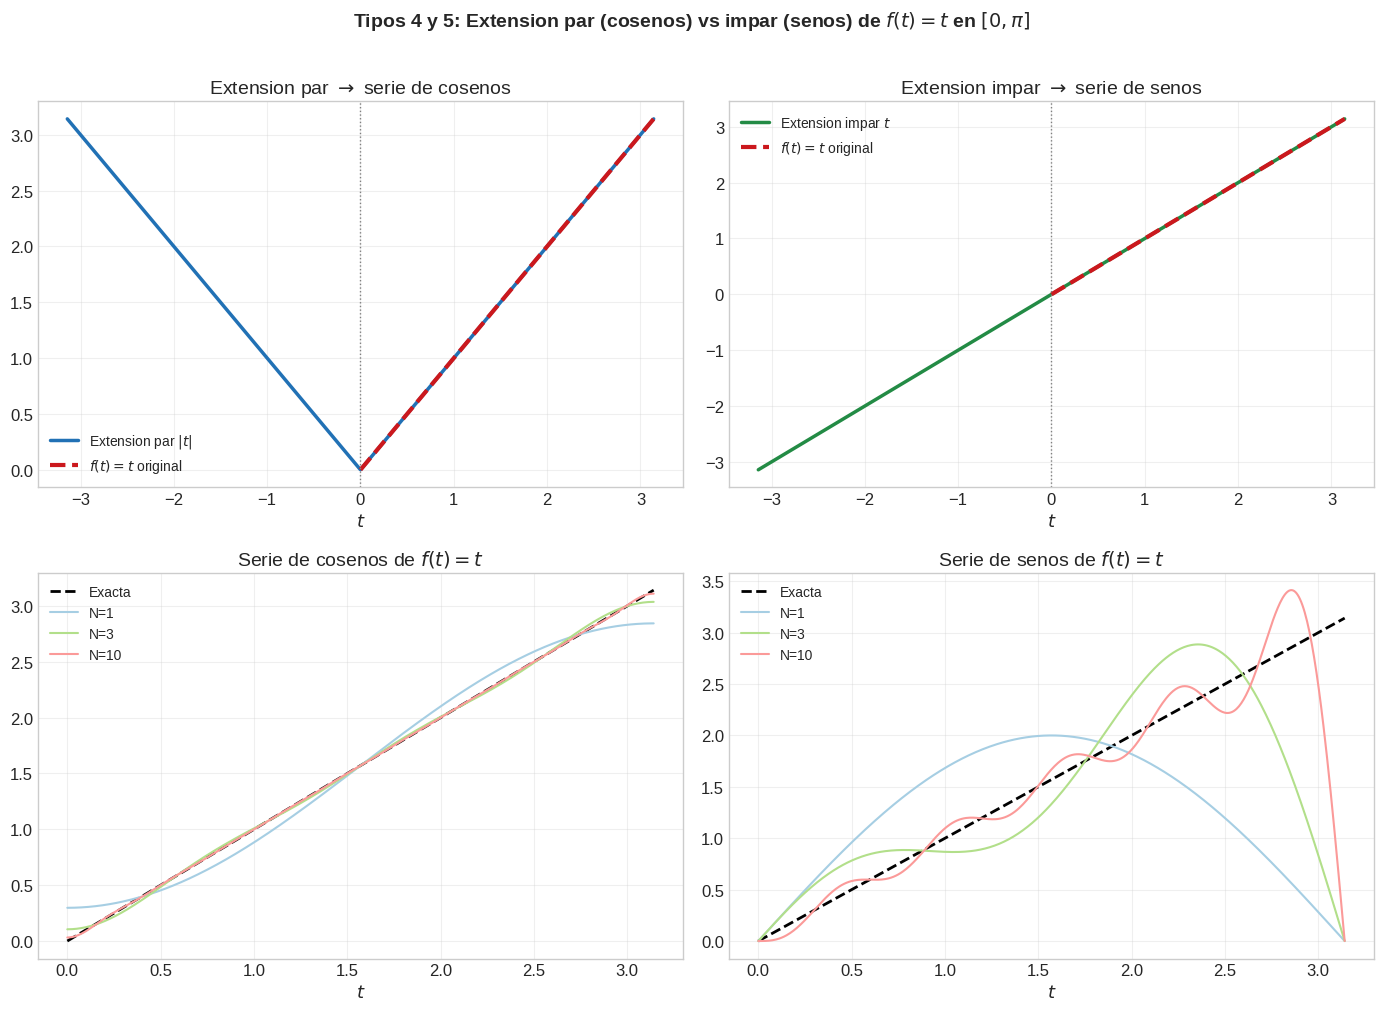

In [10]:
# Visualizacion de los tipos de series: extension par vs impar
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t_half = np.linspace(0, np.pi, 500)
t_full = np.linspace(-np.pi, np.pi, 1000)

# Funcion original en [0, pi]: f(t) = t
f_half = t_half

# Extension par
ax = axes[0, 0]
f_par = np.abs(t_full)
ax.plot(t_full, f_par, color=COLOR_PRINCIPAL, lw=2.5, label=r'Extension par $|t|$')
ax.plot(t_half, f_half, color=COLOR_RECTA, lw=3, ls='--', label=r'$f(t) = t$ original')
ax.axvline(x=0, color='gray', ls=':', lw=1)
ax.set_title(r'Extension par $\to$ serie de cosenos')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$t$')

# Extension impar
ax = axes[0, 1]
f_impar = np.sign(t_full) * np.abs(t_full)
ax.plot(t_full, f_impar, color=COLOR_PUNTO, lw=2.5, label=r'Extension impar $t$')
ax.plot(t_half, f_half, color=COLOR_RECTA, lw=3, ls='--', label=r'$f(t) = t$ original')
ax.axvline(x=0, color='gray', ls=':', lw=1)
ax.set_title(r'Extension impar $\to$ serie de senos')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$t$')

# Serie de cosenos aproximacion
ax = axes[1, 0]
ax.plot(t_half, f_half, 'k--', lw=2, label='Exacta')
for i, N in enumerate([1, 3, 10]):
    approx = np.pi / 2 * np.ones_like(t_half)
    for k in range(N):
        n = 2 * k + 1
        approx -= (4 / (np.pi * n**2)) * np.cos(n * t_half)
    ax.plot(t_half, approx, color=COLORES_N[2 * i], lw=1.5, label=f'N={N}')
ax.set_title(r'Serie de cosenos de $f(t)=t$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$t$')

# Serie de senos aproximacion
ax = axes[1, 1]
ax.plot(t_half, f_half, 'k--', lw=2, label='Exacta')
for i, N in enumerate([1, 3, 10]):
    approx = np.zeros_like(t_half)
    for n in range(1, N + 1):
        b_n = 2 * (-1)**(n + 1) / n
        approx += b_n * np.sin(n * t_half)
    ax.plot(t_half, approx, color=COLORES_N[2 * i], lw=1.5, label=f'N={N}')
ax.set_title(r'Serie de senos de $f(t)=t$')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlabel(r'$t$')

plt.suptitle(r'Tipos 4 y 5: Extension par (cosenos) vs impar (senos) de $f(t)=t$ en $[0,\pi]$',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

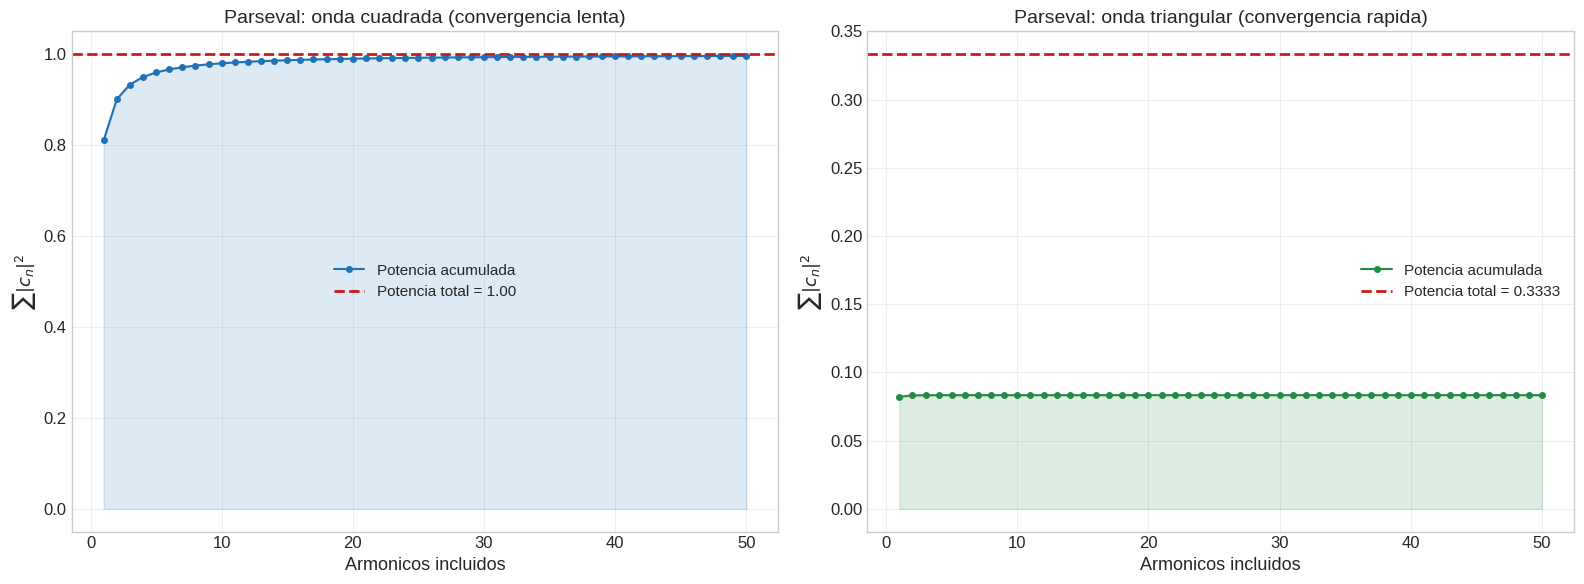

In [11]:
# Visualizacion de Parseval: potencia acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Onda cuadrada: potencia = 1
ax = axes[0]
N_max = 50
potencia_acum = np.zeros(N_max)
potencia_total = 1.0

running = 0
for i in range(N_max):
    n = 2 * i + 1
    if n <= 2 * N_max:
        cn2 = (2 / (n * np.pi))**2
        running += 2 * cn2
    potencia_acum[i] = running

ns_plot = np.arange(1, N_max + 1)
ax.plot(ns_plot, potencia_acum, 'o-', color=COLOR_PRINCIPAL, ms=4, lw=1.5,
        label='Potencia acumulada')
ax.axhline(y=potencia_total, color=COLOR_RECTA, ls='--', lw=2,
           label=f'Potencia total = {potencia_total:.2f}')
ax.fill_between(ns_plot, potencia_acum, alpha=0.15, color=COLOR_PRINCIPAL)
ax.set_xlabel(r'Armonicos incluidos')
ax.set_ylabel(r'$\sum |c_n|^2$')
ax.set_title('Parseval: onda cuadrada (convergencia lenta)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Onda triangular: potencia = 1/3
ax = axes[1]
potencia_total_tri = 1.0 / 3.0

running = 0
potencia_acum_tri = np.zeros(N_max)
for i in range(N_max):
    n = 2 * i + 1
    if n <= 2 * N_max:
        cn2 = (4 / (n**2 * np.pi**2))**2 / 4
        running += 2 * cn2
    potencia_acum_tri[i] = running

ax.plot(ns_plot, potencia_acum_tri, 'o-', color=COLOR_PUNTO, ms=4, lw=1.5,
        label='Potencia acumulada')
ax.axhline(y=potencia_total_tri, color=COLOR_RECTA, ls='--', lw=2,
           label=f'Potencia total = {potencia_total_tri:.4f}')
ax.fill_between(ns_plot, potencia_acum_tri, alpha=0.15, color=COLOR_PUNTO)
ax.set_xlabel(r'Armonicos incluidos')
ax.set_ylabel(r'$\sum |c_n|^2$')
ax.set_title('Parseval: onda triangular (convergencia rapida)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

## 11. Espectros: amplitud y fase

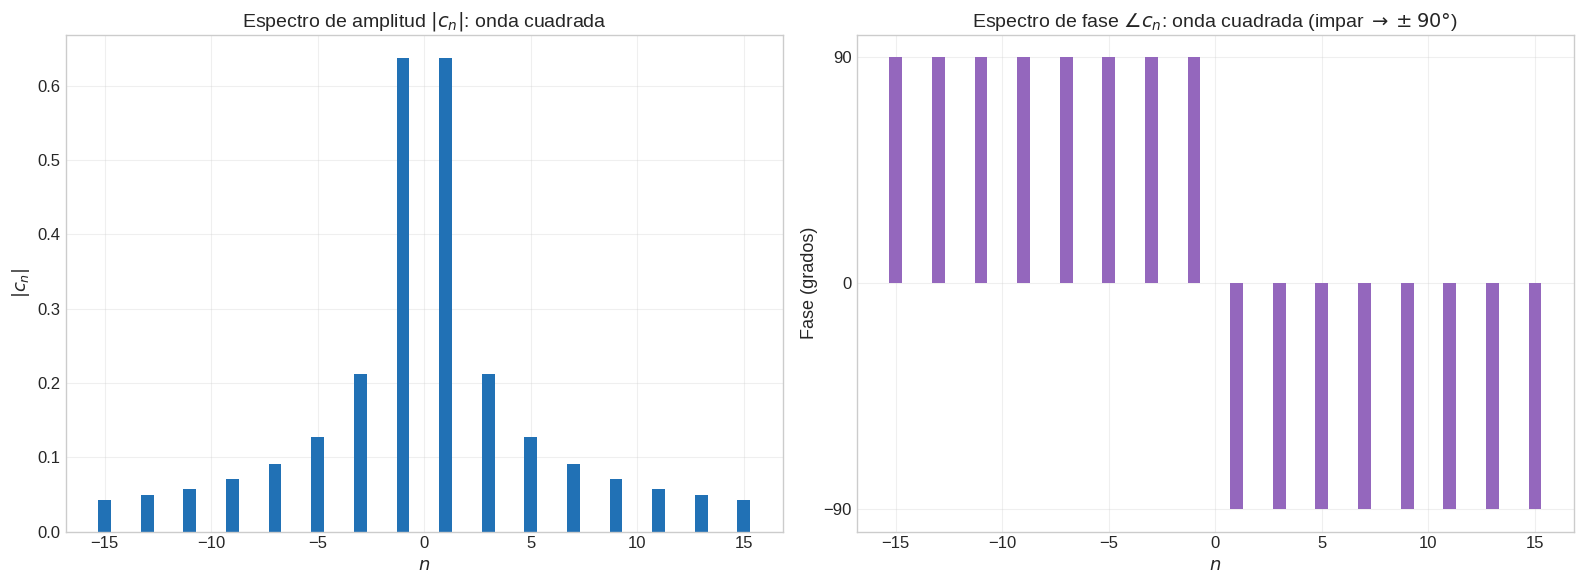

In [12]:
# Espectro complejo de la onda cuadrada (amplitud y fase)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

n_range = np.arange(-15, 16)
cn_amp = np.zeros_like(n_range, dtype=float)
cn_phase = np.zeros_like(n_range, dtype=float)

for i, n in enumerate(n_range):
    if n == 0:
        cn_amp[i] = 0
        cn_phase[i] = 0
    elif n % 2 != 0:  # Impar
        cn_amp[i] = 2 / (abs(n) * np.pi)
        cn_phase[i] = -np.pi / 2 * np.sign(n)
    else:
        cn_amp[i] = 0
        cn_phase[i] = 0

# Amplitud
ax = axes[0]
ax.bar(n_range, cn_amp, color=COLOR_PRINCIPAL, width=0.6)
ax.set_xlabel(r'$n$')
ax.set_ylabel(r'$|c_n|$')
ax.set_title(r'Espectro de amplitud $|c_n|$: onda cuadrada')
ax.grid(True, alpha=0.3)

# Fase
ax = axes[1]
mask = cn_amp > 0.001
ax.bar(n_range[mask], cn_phase[mask] * 180 / np.pi, color=COLOR_AUX2, width=0.6)
ax.set_xlabel(r'$n$')
ax.set_ylabel(r'Fase (grados)')
ax.set_title(r'Espectro de fase $\angle c_n$: onda cuadrada (impar $\to \pm 90°$)')
ax.set_yticks([-90, 0, 90])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observación clave:** para la onda cuadrada (función real e impar):
- $|c_n| = |c_{-n}|$ (simetría conjugada, pues $f$ es real)
- $\angle c_n = -90°$ para $n > 0$ y $\angle c_n = +90°$ para $n < 0$ (pues $f$ es impar $\to$ $c_n$ puramente imaginario)
- Solo aparecen armónicos impares (simetría de media onda)

---

## 12. Resumen de fórmulas y tabla de reconocimiento rápido

### 12.1 Fórmulas principales

| Fórmula | Uso |
|---------|-----|
| $a_0 = \frac{2}{T}\int f\,dt$ | Valor medio $\times 2$ |
| $a_n = \frac{2}{T}\int f\cos(n\omega t)\,dt$ | Coeficiente coseno |
| $b_n = \frac{2}{T}\int f\sin(n\omega t)\,dt$ | Coeficiente seno |
| $c_n = \frac{1}{T}\int f\,e^{-jn\omega t}\,dt$ | Coeficiente complejo |
| $c_n = \frac{a_n - jb_n}{2}$ | Relación complejo-trigonométrico |
| $\frac{1}{T}\int|f|^2\,dt = \sum|c_n|^2$ | **Parseval** |
| $S(t_0) = \frac{f(t_0^+)+f(t_0^-)}{2}$ | Convergencia en discontinuidad |

### 12.2 Cheat sheet de reconocimiento de patrones

| Observación | Conclusión | Ahorro |
|-------------|-----------|--------|
| $f(-t) = f(t)$ | $b_n = 0$ | No calcular senos |
| $f(-t) = -f(t)$ | $a_0 = a_n = 0$ | No calcular cosenos |
| $f(t+T/2) = -f(t)$ | $c_{2k} = 0$ | Solo armónicos impares |
| Par + media onda | Solo $a_n$ con $n$ impar | Máximo ahorro |
| Impar + media onda | Solo $b_n$ con $n$ impar | Máximo ahorro |
| "Serie de senos en $[0,L]$" | Extensión impar | Solo calcular $b_n$ |
| "Serie de cosenos en $[0,L]$" | Extensión par | Solo calcular $a_n$ |
| $f$ continua | $|c_n| \sim 1/n^2$ | Pocas parciales bastan |
| $f$ con saltos | $|c_n| \sim 1/n$ | Muchas parciales necesarias |
| Identidad trigonométrica obvia | Simplificar primero | Quizás no hay que integrar |

### 12.3 Tabla de series clásicas

| Función | Serie | Coeficientes no nulos |
|---------|-------|-----------------------|
| Onda cuadrada | $\frac{4}{\pi}\sum \frac{\sin((2k+1)t)}{2k+1}$ | $b_{\text{impar}}$ |
| Diente de sierra | $2\sum \frac{(-1)^{n+1}}{n}\sin(nt)$ | Todos los $b_n$ |
| Onda triangular | $\frac{8}{\pi^2}\sum \frac{(-1)^{(n-1)/2}}{n^2}\sin(nt)$ ($n$ impar) | $b_{\text{impar}}$ |
| $t^2$ en $[-\pi,\pi]$ | $\frac{\pi^2}{3} + 4\sum\frac{(-1)^n}{n^2}\cos(nt)$ | Todos los $a_n$ |
| $|\sin t|$ | $\frac{2}{\pi} - \frac{4}{\pi}\sum\frac{\cos(2kt)}{4k^2-1}$ | $a_{\text{par}}$ |
| $e^t$ en $[-\pi,\pi]$ | $\frac{\sinh\pi}{\pi}\sum\frac{(-1)^n}{1+n^2}[\cos(nt)-n\sin(nt)]$ | Todos $a_n, b_n$ |

### 12.4 Sumas clásicas obtenidas por Fourier/Parseval

| Suma | Valor | Obtenida de |
|------|-------|-------------|
| $\sum \frac{(-1)^{k}}{2k+1} = 1 - \frac{1}{3} + \frac{1}{5} - \cdots$ | $\frac{\pi}{4}$ | Onda cuadrada en $t=\pi/2$ |
| $\sum \frac{1}{n^2}$ | $\frac{\pi^2}{6}$ | Parseval de $f=t$ o evaluación de $t^2$ |
| $\sum \frac{(-1)^{n+1}}{n^2}$ | $\frac{\pi^2}{12}$ | $t^2$ evaluada en $t=0$ |
| $\sum \frac{1}{(2n-1)^2}$ | $\frac{\pi^2}{8}$ | Parseval de onda cuadrada |
| $\sum \frac{1}{n^4}$ | $\frac{\pi^4}{90}$ | Parseval de $f=t^2$ |
| $\sum \frac{1}{(2n-1)^4}$ | $\frac{\pi^4}{96}$ | Parseval de onda triangular |

---

## 13. Metodología de resolución paso a paso

Ante cualquier problema de series de Fourier, seguir este algoritmo:

1. **Identificar el intervalo y el periodo.** $[-\pi, \pi]$, $[0, L]$, $[-L, L]$, $[0, 2\pi]$...
2. **Determinar el tipo de serie pedido:** completa, solo senos, solo cosenos, compleja.
3. **Analizar simetrías** (tabla de patrones): par, impar, media onda. **Esto es lo MÁS importante.**
4. **Simplificar** con identidades trigonométricas si es posible.
5. **Calcular los coeficientes no nulos** (solo los que la simetría no anula).
6. **Verificar:** evaluar la serie en un punto conocido (ej. $t = 0$) y comprobar coherencia.
7. **Si piden convergencia en un punto:** usar $\frac{f(t_0^+) + f(t_0^-)}{2}$.
8. **Si piden sumar una serie numérica:** usar Parseval o evaluación puntual.

**Error frecuente n.1:** Calcular $a_n$ y $b_n$ de una función par (los $b_n$ son cero, tiempo perdido).

**Error frecuente n.2:** Olvidar que en los extremos de la extensión impar la serie converge a $0$, no al valor de $f$.

**Error frecuente n.3:** Confundir $\omega = 2\pi/T$ con $\omega = \pi/L$. En $[-L, L]$ el periodo es $2L$ y $\omega = \pi/L$.